# Predicción de churn en telecomunicaciones mediante variables económicas y experiencia de cliente

## Introducción

Análisis y predicción de churn en telecom

El churn o abandono de clientes representa uno de los principales problemas en empresas del sector telecomunicaciones, ya que implica pérdida de ingresos y aumento de costes de captación de nuevos clientes.

El presente trabajo tiene como objetivo analizar los factores asociados al churn utilizando distintas fuentes de información relacionadas con el perfil del cliente, comportamiento económico e interacciones con soporte técnico.

A través de técnicas de análisis exploratorio de datos, ingeniería de variables y modelos predictivos, se busca identificar patrones de comportamiento que permitan anticipar el riesgo de abandono y generar conclusiones útiles desde una perspectiva de negocio.

Los datasets utilizados incluyen información estructural de clientes, facturación mensual, incidencias de soporte y etiquetas de churn.

## Librerías

In [1]:
# ================================
# LIBRERÍAS
# ================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# LIBRERÍAS TEST ESTADÍSTICOS

from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

## Funciones Aux.

In [2]:
# ====================================
# FUNCIONES AUXILIARES
# ====================================

def porcentaje_nulos(df):
    
    porcentaje = (
        df.isnull()
        .sum()
        .sort_values(ascending=False)
        / len(df)
    ) * 100
    
    return porcentaje

## Carga de datos

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

clientes = pd.read_csv(
    "/Users/fran/Desktop/UCV Master /11.- Practicas/UCV-Churn/data/raw/clientes.csv"
)

facturacion = pd.read_csv(
    "/Users/fran/Desktop/UCV Master /11.- Practicas/UCV-Churn/data/raw/facturacion_mensual.csv"
)

soporte = pd.read_csv(
    "/Users/fran/Desktop/UCV Master /11.- Practicas/UCV-Churn/data/raw/interacciones_soporte.csv"
)

churn = pd.read_csv(
    "/Users/fran/Desktop/UCV Master /11.- Practicas/UCV-Churn/data/raw/churn_target.csv"
)

print("Columnas facturacion:")
print(facturacion.columns)

print("\nColumnas soporte:")
print(soporte.columns)

Columnas facturacion:
Index(['cliente_id', 'fecha', 'zona_id', 'tipo_plan', 'num_lineas',
       'cargo_base', 'consumo_extra', 'descuento_aplicado', 'importe_total',
       'dias_retraso_pago', 'impago_flag', 'variacion_consumo_pct',
       'stress_calidad_lag', 'incidencia_masiva_lag'],
      dtype='str')

Columnas soporte:
Index(['interaccion_id', 'cliente_id', 'fecha_evento', 'mes', 'canal',
       'motivo', 'duracion_min', 'resuelto', 'satisfaccion_post',
       'stress_calidad_lag', 'incidencia_masiva_lag', 'impago_mes',
       'dias_retraso_mes'],
      dtype='str')


## Secciones

In [4]:
# 1. Inspección inicial

# Clientes

clientes.head()

,cliente_id,zona_id,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,num_lineas,tipo_plan,tipo_dispositivo,ingreso_estimado,antiguedad_meses,descuento_activo
0,C000001,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,2,Prepago,Gama alta,4335.0,72.0,0
1,C000002,Z15,Oeste,suburbana,62939,54.0,M,Casado/a,2,Premium,Gama media,4609.0,35.0,1
2,C000003,Z27,Norte,suburbana,42704,54.0,M,Casado/a,3,Prepago,Gama baja,1836.0,11.0,0
3,C000004,Z22,Este,suburbana,53534,34.0,M,Soltero/a,1,Prepago,Gama media,2318.0,13.0,0
4,C000005,Z04,Centro,suburbana,55457,46.0,F,Soltero/a,2,Contrato,Gama media,2184.0,21.0,0


In [5]:
clientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 10150 entries, 0 to 10149
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cliente_id        10150 non-null  str    
 1   zona_id           10150 non-null  str    
 2   region            10150 non-null  str    
 3   tipo_zona         10150 non-null  str    
 4   poblacion_zona    10150 non-null  int64  
 5   edad              9845 non-null   float64
 6   sexo              10105 non-null  str    
 7   estado_civil      10071 non-null  str    
 8   num_lineas        10150 non-null  int64  
 9   tipo_plan         10150 non-null  str    
 10  tipo_dispositivo  10150 non-null  str    
 11  ingreso_estimado  9846 non-null   float64
 12  antiguedad_meses  9845 non-null   float64
 13  descuento_activo  10150 non-null  int64  
dtypes: float64(3), int64(3), str(8)
memory usage: 1.6 MB


In [6]:
clientes.describe(include='all')

,cliente_id,zona_id,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,num_lineas,tipo_plan,tipo_dispositivo,ingreso_estimado,antiguedad_meses,descuento_activo
count,10150,10150,10150,10150,10150.000000,9845.000000,10105,10071,10150.000000,10150,10150,9846.000000,9845.000000,10150.000000
unique,10000,31,5,3,NaN,NaN,4,4,NaN,3,3,NaN,NaN,NaN
top,C000006,Z26,Oeste,urbana_premium,NaN,NaN,F,Soltero/a,NaN,Premium,Gama media,NaN,NaN,NaN
freq,2,824,3064,4548,NaN,NaN,5125,5584,NaN,5136,6149,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,59980.388571,39.324835,NaN,NaN,2.306207,NaN,NaN,3478.701503,32.599289,0.254975
std,NaN,NaN,NaN,NaN,28712.477075,11.974293,NaN,NaN,1.015997,NaN,NaN,1411.966698,22.512614,0.435869
min,NaN,NaN,NaN,NaN,11707.000000,18.000000,NaN,NaN,1.000000,NaN,NaN,900.000000,-110.000000,0.000000
25%,NaN,NaN,NaN,NaN,41163.000000,31.000000,NaN,NaN,2.000000,NaN,NaN,2467.000000,18.000000,0.000000
50%,NaN,NaN,NaN,NaN,56480.500000,39.000000,NaN,NaN,2.000000,NaN,NaN,3219.000000,29.000000,0.000000
75%,NaN,NaN,NaN,NaN,72683.000000,47.000000,NaN,NaN,3.000000,NaN,NaN,4195.000000,44.000000,1.000000


In [7]:
# ====================================
# VALORES NULOS
# ====================================

porcentaje_nulos(clientes)

edad                3.004926
antiguedad_meses    3.004926
ingreso_estimado    2.995074
estado_civil        0.778325
sexo                0.443350
cliente_id          0.000000
zona_id             0.000000
region              0.000000
tipo_zona           0.000000
poblacion_zona      0.000000
num_lineas          0.000000
tipo_plan           0.000000
tipo_dispositivo    0.000000
descuento_activo    0.000000
dtype: float64

# 1. Análisis exploratorio de datos (EDA)

In [8]:
## 1.1 Variable objetivo

churn.head()

,cliente_id,fecha,churn
0,C000001,2023-01-01,0
1,C000001,2023-02-01,0
2,C000001,2023-03-01,0
3,C000001,2023-04-01,0
4,C000001,2023-05-01,0


In [9]:
churn['churn'].value_counts()

churn
0    319987
1      2000
Name: count, dtype: int64

In [10]:
churn['churn'].value_counts(normalize=True) * 100

churn
0    99.378857
1     0.621143
Name: proportion, dtype: float64

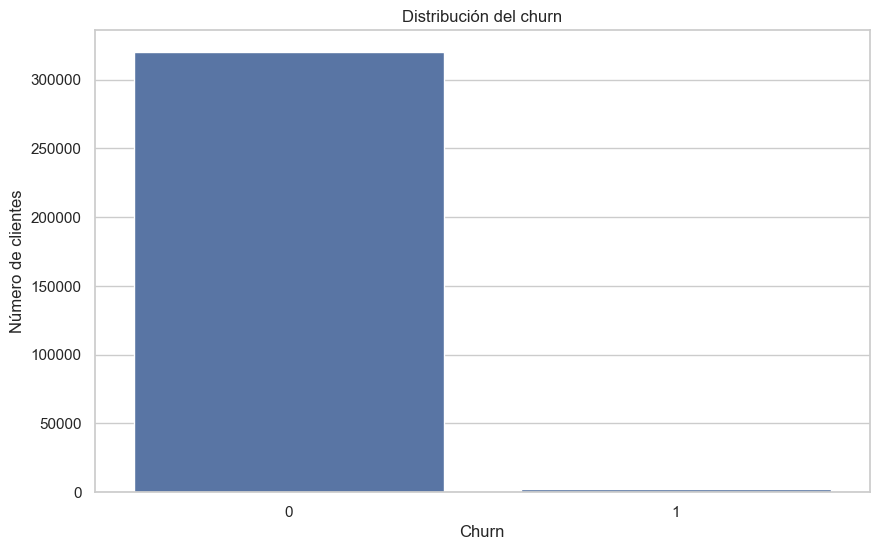

In [11]:
# Gráfico
sns.countplot(
    data=churn,
    x='churn'
)

plt.title("Distribución del churn")

plt.xlabel("Churn")

plt.ylabel("Número de clientes")

plt.show()

### Interpretación

La variable objetivo presenta desbalanceo moderado, ya que el número de clientes que permanecen en la compañía es superior al número de clientes que abandonan el servicio.

Este comportamiento es habitual en problemas reales de churn y deberá tenerse en cuenta en fases posteriores del modelado.

In [12]:
clientes.columns

Index(['cliente_id', 'zona_id', 'region', 'tipo_zona', 'poblacion_zona',
       'edad', 'sexo', 'estado_civil', 'num_lineas', 'tipo_plan',
       'tipo_dispositivo', 'ingreso_estimado', 'antiguedad_meses',
       'descuento_activo'],
      dtype='str')

In [13]:
churn.columns

Index(['cliente_id', 'fecha', 'churn'], dtype='str')

In [14]:
df = clientes.merge(
    churn,
    on='cliente_id',
    how='inner'
)

df.head()

,cliente_id,zona_id,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,num_lineas,tipo_plan,tipo_dispositivo,ingreso_estimado,antiguedad_meses,descuento_activo,fecha,churn
0,C000001,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,2,Prepago,Gama alta,4335.0,72.0,0,2023-01-01,0
1,C000001,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,2,Prepago,Gama alta,4335.0,72.0,0,2023-02-01,0
2,C000001,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,2,Prepago,Gama alta,4335.0,72.0,0,2023-03-01,0
3,C000001,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,2,Prepago,Gama alta,4335.0,72.0,0,2023-04-01,0
4,C000001,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,2,Prepago,Gama alta,4335.0,72.0,0,2023-05-01,0


## 1.2 Perfil de clientes y churn

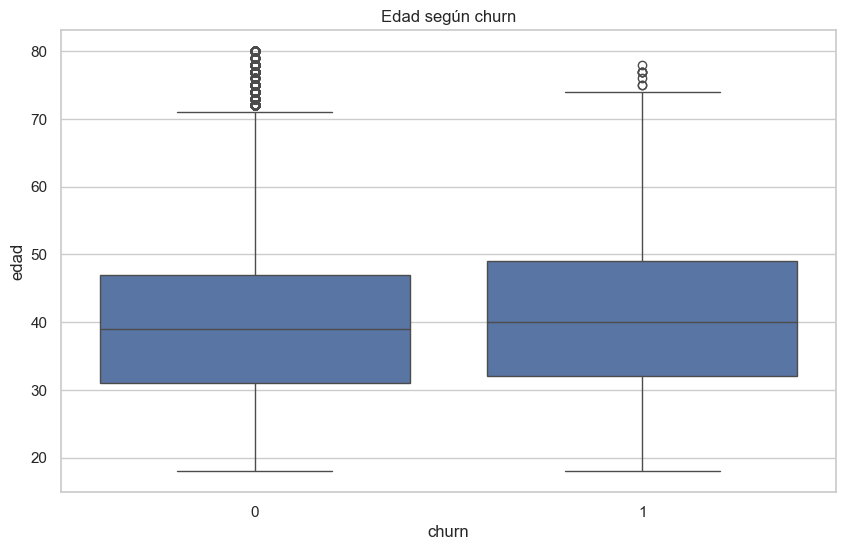

In [15]:
sns.boxplot(
    data=df,
    x='churn',
    y='edad'
)

plt.title("Edad según churn")

plt.show()

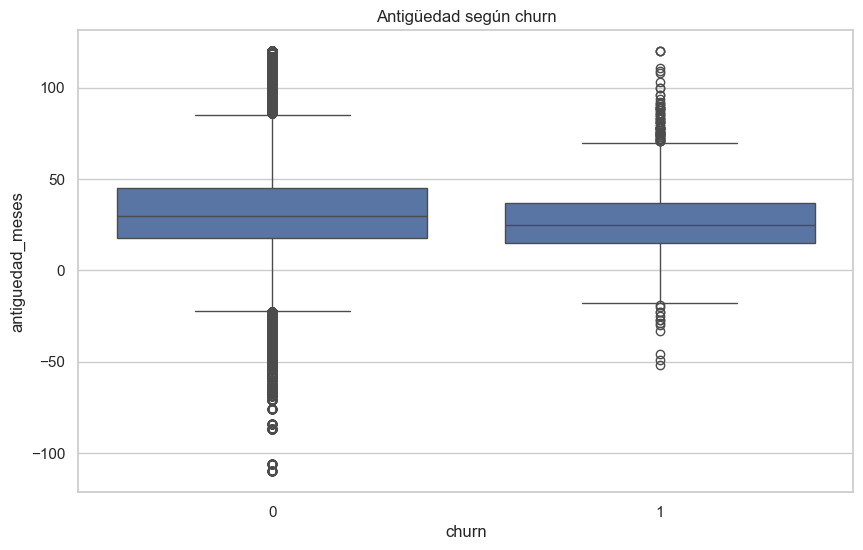

In [16]:
sns.boxplot(
    data=df,
    x='churn',
    y='antiguedad_meses'
)

plt.title("Antigüedad según churn")

plt.show()

In [17]:
tabla_plan = pd.crosstab(
    df['tipo_plan'],
    df['churn'],
    normalize='index'
) * 100

tabla_plan

churn,0,1
tipo_plan,,
Contrato,99.334972,0.665028
Premium,99.512681,0.487319
Prepago,99.155928,0.844072


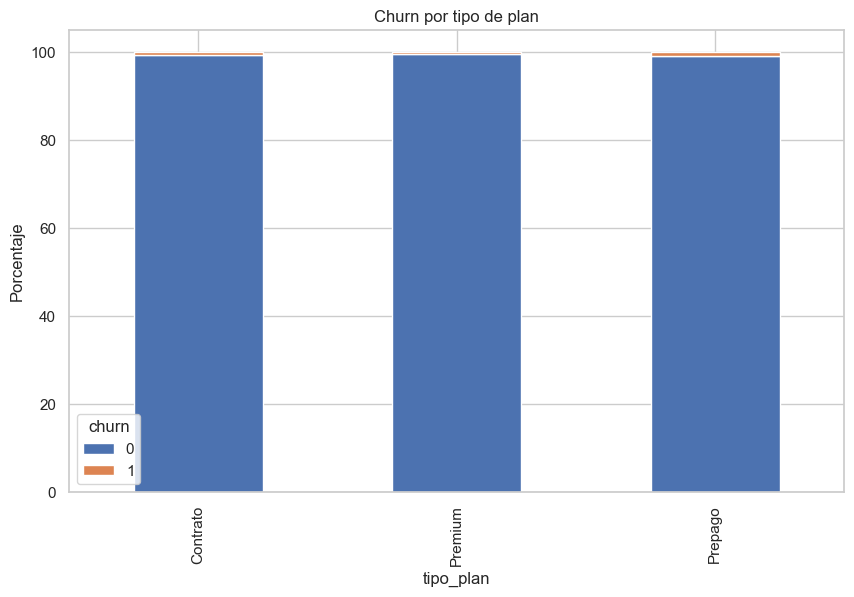

In [18]:
tabla_plan.plot(
    kind='bar',
    stacked=True
)

plt.title("Churn por tipo de plan")

plt.ylabel("Porcentaje")

plt.show()

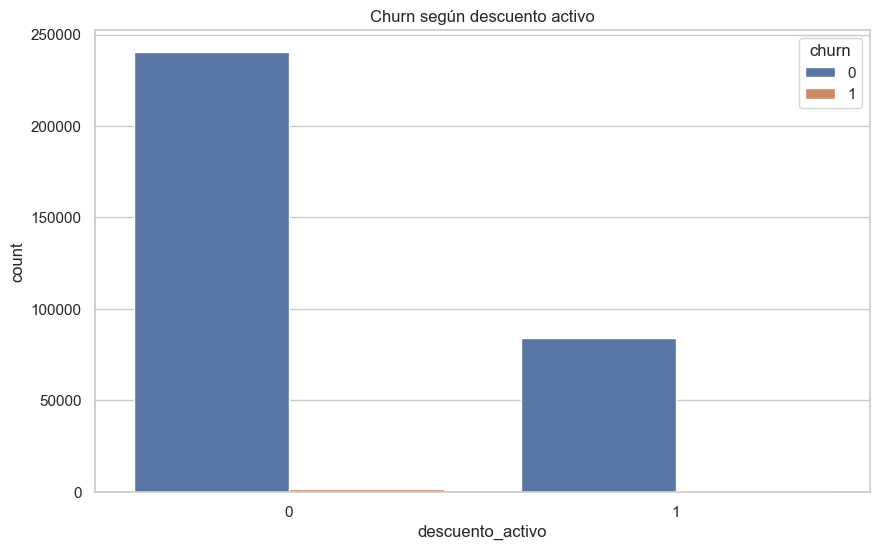

In [19]:
sns.countplot(
    data=df,
    x='descuento_activo',
    hue='churn'
)

plt.title("Churn según descuento activo")

plt.show()

## Conclusiones parciales

A partir del análisis exploratorio inicial se observan diferencias relevantes entre distintos perfiles de clientes.

Variables como la antigüedad, el tipo de plan y la presencia de descuentos parecen mostrar relación con la probabilidad de churn.

Estos resultados permiten plantear hipótesis iniciales que serán analizadas posteriormente mediante técnicas de modelado predictivo.

## FACTURACIÓN


In [20]:
facturacion.columns

Index(['cliente_id', 'fecha', 'zona_id', 'tipo_plan', 'num_lineas',
       'cargo_base', 'consumo_extra', 'descuento_aplicado', 'importe_total',
       'dias_retraso_pago', 'impago_flag', 'variacion_consumo_pct',
       'stress_calidad_lag', 'incidencia_masiva_lag'],
      dtype='str')

In [21]:
facturacion.head()

,cliente_id,fecha,zona_id,tipo_plan,num_lineas,cargo_base,consumo_extra,descuento_aplicado,importe_total,dias_retraso_pago,impago_flag,variacion_consumo_pct,stress_calidad_lag,incidencia_masiva_lag
0,C000001,2023-01-01,Z26,Prepago,2,43.65,6.98,0.0,50.62,0,0,0.000,0.0000,0
1,C000001,2023-02-01,Z26,Prepago,2,43.65,10.33,0.0,53.98,0,0,0.481,0.4104,0
2,C000001,2023-03-01,Z26,Prepago,2,43.65,10.87,0.0,54.52,0,0,0.052,0.4221,0
3,C000001,2023-04-01,Z26,Prepago,2,43.65,6.82,0.0,50.47,0,0,-0.372,0.4301,0
4,C000001,2023-05-01,Z26,Prepago,2,43.65,13.26,0.0,56.90,0,0,0.943,0.4486,0


## SOPORTE


In [22]:
soporte.columns

Index(['interaccion_id', 'cliente_id', 'fecha_evento', 'mes', 'canal',
       'motivo', 'duracion_min', 'resuelto', 'satisfaccion_post',
       'stress_calidad_lag', 'incidencia_masiva_lag', 'impago_mes',
       'dias_retraso_mes'],
      dtype='str')

In [23]:
soporte.head()

,interaccion_id,cliente_id,fecha_evento,mes,canal,motivo,duracion_min,resuelto,satisfaccion_post,stress_calidad_lag,incidencia_masiva_lag,impago_mes,dias_retraso_mes
0,I923052492930,C000001,2023-02-07,2023-02-01,telefono,Facturación,9.5,0,4.0,0.4104,0,0,0
1,I692361171059,C000001,2023-04-20,2023-04-01,app_chat,Facturación,3.9,1,4.0,0.4301,0,0,0
2,I354109146175,C000001,2023-04-27,2023-04-01,app_chat,Baja / portabilidad,2.8,1,5.0,0.4301,0,0,0
3,I986032353420,C000001,2023-05-04,2023-05-01,telefono,Consulta general,8.4,1,3.0,0.4486,0,0,0
4,I553023863181,C000001,2023-06-26,2023-06-01,telefono,Impago / pago,4.5,1,4.0,0.3936,0,0,0


## CHURN

In [24]:
churn.head()


,cliente_id,fecha,churn
0,C000001,2023-01-01,0
1,C000001,2023-02-01,0
2,C000001,2023-03-01,0
3,C000001,2023-04-01,0
4,C000001,2023-05-01,0


# 2. Integración y preparación de datos

In [25]:
# ====================================
# CONVERSIÓN DE FECHAS
# ====================================

facturacion['fecha'] = pd.to_datetime(
    facturacion['fecha'],
    format='mixed',
    dayfirst=True
)

churn['fecha'] = pd.to_datetime(
    churn['fecha'],
    format='mixed',
    dayfirst=True
)

soporte['mes'] = pd.to_datetime(
    soporte['mes'],
    format='mixed',
    dayfirst=True
)

In [26]:
soporte = soporte.rename(
    columns={'mes': 'fecha'}
)

In [27]:
df = churn.merge(
    clientes,
    on='cliente_id',
    how='left'
)

In [28]:
df = df.merge(
    facturacion,
    on=['cliente_id', 'fecha'],
    how='left'
)

In [29]:
# ====================================
# AGREGACIÓN SOPORTE
# ====================================

soporte_agg = soporte.groupby(
    ['cliente_id', 'fecha']
).agg({
    
    'interaccion_id': 'count',
    'duracion_min': 'mean',
    'resuelto': 'mean',
    'satisfaccion_post': 'mean',
    'impago_mes': 'max',
    'dias_retraso_mes': 'mean'
    
}).reset_index()

In [30]:
soporte_agg.columns = [
    'cliente_id',
    'fecha',
    'num_interacciones',
    'duracion_media',
    'ratio_resolucion',
    'satisfaccion_media',
    'impago_mes',
    'dias_retraso'
]

soporte_agg.head()

,cliente_id,fecha,num_interacciones,duracion_media,ratio_resolucion,satisfaccion_media,impago_mes,dias_retraso
0,C000001,2023-01-02,1,9.50,0.0,4.0,0,0.0
1,C000001,2023-01-04,2,3.35,1.0,4.5,0,0.0
2,C000001,2023-01-05,1,8.40,1.0,3.0,0,0.0
3,C000001,2023-01-06,1,4.50,1.0,4.0,0,0.0
4,C000001,2023-01-10,1,7.90,1.0,4.0,0,0.0


In [31]:
# ====================================
# MERGE SOPORTE
# ====================================

df = df.merge(
    soporte_agg,
    on=['cliente_id', 'fecha'],
    how='left'
)

df.head()

,cliente_id,fecha,churn,zona_id_x,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,...,impago_flag,variacion_consumo_pct,stress_calidad_lag,incidencia_masiva_lag,num_interacciones,duracion_media,ratio_resolucion,satisfaccion_media,impago_mes,dias_retraso
0,C000001,2023-01-01,0,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,...,0.0,0.000,0.0000,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,C000001,2023-01-02,0,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,...,0.0,0.481,0.4104,0.0,1.0,9.50,0.0,4.0,0.0,0.0
2,C000001,2023-01-03,0,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,...,0.0,0.052,0.4221,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,C000001,2023-01-04,0,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,...,0.0,-0.372,0.4301,0.0,2.0,3.35,1.0,4.5,0.0,0.0
4,C000001,2023-01-05,0,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,...,0.0,0.943,0.4486,0.0,1.0,8.40,1.0,3.0,0.0,0.0


In [32]:
df.shape

(331690, 34)

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 331690 entries, 0 to 331689
Data columns (total 34 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   cliente_id             331690 non-null  str           
 1   fecha                  331690 non-null  datetime64[us]
 2   churn                  331690 non-null  int64         
 3   zona_id_x              331690 non-null  str           
 4   region                 331690 non-null  str           
 5   tipo_zona              331690 non-null  str           
 6   poblacion_zona         331690 non-null  int64         
 7   edad                   321758 non-null  float64       
 8   sexo                   330275 non-null  str           
 9   estado_civil           329101 non-null  str           
 10  num_lineas_x           331690 non-null  int64         
 11  tipo_plan_x            331690 non-null  str           
 12  tipo_dispositivo       331690 non-null  str           


# 3. Limpieza y preparación del dataset

In [34]:
# ====================================
# ELIMINAR COLUMNAS DUPLICADAS
# ====================================

df = df.drop(columns=[
    
    'zona_id_y',
    'tipo_plan_y',
    'num_lineas_y'
    
])

In [35]:
df = df.rename(columns={
    
    'zona_id_x': 'zona_id',
    'tipo_plan_x': 'tipo_plan',
    'num_lineas_x': 'num_lineas'
    
})

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 331690 entries, 0 to 331689
Data columns (total 31 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   cliente_id             331690 non-null  str           
 1   fecha                  331690 non-null  datetime64[us]
 2   churn                  331690 non-null  int64         
 3   zona_id                331690 non-null  str           
 4   region                 331690 non-null  str           
 5   tipo_zona              331690 non-null  str           
 6   poblacion_zona         331690 non-null  int64         
 7   edad                   321758 non-null  float64       
 8   sexo                   330275 non-null  str           
 9   estado_civil           329101 non-null  str           
 10  num_lineas             331690 non-null  int64         
 11  tipo_plan              331690 non-null  str           
 12  tipo_dispositivo       331690 non-null  str           


In [37]:
nulos = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

nulos[nulos > 0]

satisfaccion_media       148737
dias_retraso             147161
num_interacciones        147161
impago_mes               147161
ratio_resolucion         147161
duracion_media           147161
importe_total             14255
ingreso_estimado           9933
edad                       9932
antiguedad_meses           9927
dias_retraso_pago          4465
stress_calidad_lag         4465
variacion_consumo_pct      4465
impago_flag                4465
cargo_base                 4465
consumo_extra              4465
descuento_aplicado         4465
incidencia_masiva_lag      4465
estado_civil               2589
sexo                       1415
dtype: int64

## 3.1 Tratamiento de valores nulos

In [38]:
# ====================================
# IMPUTACIÓN VARIABLES SOPORTE
# ====================================

df['num_interacciones'] = df['num_interacciones'].fillna(0)

df['duracion_media'] = df['duracion_media'].fillna(0)

df['ratio_resolucion'] = df['ratio_resolucion'].fillna(0)

df['satisfaccion_media'] = df['satisfaccion_media'].fillna(0)

df['impago_mes'] = df['impago_mes'].fillna(0)

df['dias_retraso'] = df['dias_retraso'].fillna(0)

In [39]:
df['edad'] = df['edad'].fillna(
    df['edad'].median()
)

df['ingreso_estimado'] = df['ingreso_estimado'].fillna(
    df['ingreso_estimado'].median()
)

df['antiguedad_meses'] = df['antiguedad_meses'].fillna(
    df['antiguedad_meses'].median()
)

In [40]:
df['sexo'] = df['sexo'].fillna(
    df['sexo'].mode()[0]
)

df['estado_civil'] = df['estado_civil'].fillna(
    df['estado_civil'].mode()[0]
)

In [41]:
df.isnull().sum().sort_values(ascending=False)

importe_total            14255
cargo_base                4465
incidencia_masiva_lag     4465
stress_calidad_lag        4465
variacion_consumo_pct     4465
impago_flag               4465
dias_retraso_pago         4465
descuento_aplicado        4465
consumo_extra             4465
cliente_id                   0
impago_mes                   0
satisfaccion_media           0
ratio_resolucion             0
duracion_media               0
num_interacciones            0
descuento_activo             0
fecha                        0
antiguedad_meses             0
ingreso_estimado             0
tipo_dispositivo             0
tipo_plan                    0
num_lineas                   0
estado_civil                 0
sexo                         0
edad                         0
poblacion_zona               0
tipo_zona                    0
region                       0
zona_id                      0
churn                        0
dias_retraso                 0
dtype: int64

In [42]:
# ====================================
# IMPUTACIÓN VARIABLES FACTURACIÓN
# ====================================

# Variables numéricas continuas
variables_numericas = [

    'cargo_base',
    'consumo_extra',
    'descuento_aplicado',
    'importe_total',
    'dias_retraso_pago',
    'variacion_consumo_pct'

]

# Imputación con mediana
for col in variables_numericas:

    df[col] = df[col].fillna(
        df[col].median()
    )

# ====================================
# VARIABLES BINARIAS / EVENTOS
# ====================================

# Si no hay registro de impago,
# asumimos ausencia de impago

df['impago_flag'] = df['impago_flag'].fillna(0)

# Si no aparece incidencia masiva,
# asumimos ausencia de incidencia

df['incidencia_masiva_lag'] = (
    df['incidencia_masiva_lag']
    .fillna(0)
)

# Stress de calidad:
# imputación conservadora con mediana

df['stress_calidad_lag'] = (
    df['stress_calidad_lag']
    .fillna(
        df['stress_calidad_lag'].median()
    )
)

### Justificación de imputación de valores nulos

El tratamiento de valores nulos se realizó considerando el significado de cada variable y el contexto de negocio.

En variables numéricas continuas, como importe_total o dias_retraso_pago, se utilizó imputación mediante mediana para reducir el impacto de posibles valores extremos.

En variables binarias o relacionadas con eventos, como impago_flag o incidencia_masiva_lag, los valores nulos se interpretaron como ausencia del evento correspondiente, imputándose con valor 0.

Este enfoque permite preservar mejor la coherencia semántica de los datos y evita introducir supuestos incorrectos sobre el comportamiento del cliente.

In [43]:
df.isnull().sum().sort_values(ascending=False)

cliente_id               0
cargo_base               0
impago_mes               0
satisfaccion_media       0
ratio_resolucion         0
duracion_media           0
num_interacciones        0
incidencia_masiva_lag    0
stress_calidad_lag       0
variacion_consumo_pct    0
impago_flag              0
dias_retraso_pago        0
importe_total            0
descuento_aplicado       0
consumo_extra            0
descuento_activo         0
fecha                    0
antiguedad_meses         0
ingreso_estimado         0
tipo_dispositivo         0
tipo_plan                0
num_lineas               0
estado_civil             0
sexo                     0
edad                     0
poblacion_zona           0
tipo_zona                0
region                   0
zona_id                  0
churn                    0
dias_retraso             0
dtype: int64

# 4. Análisis exploratorio avanzado

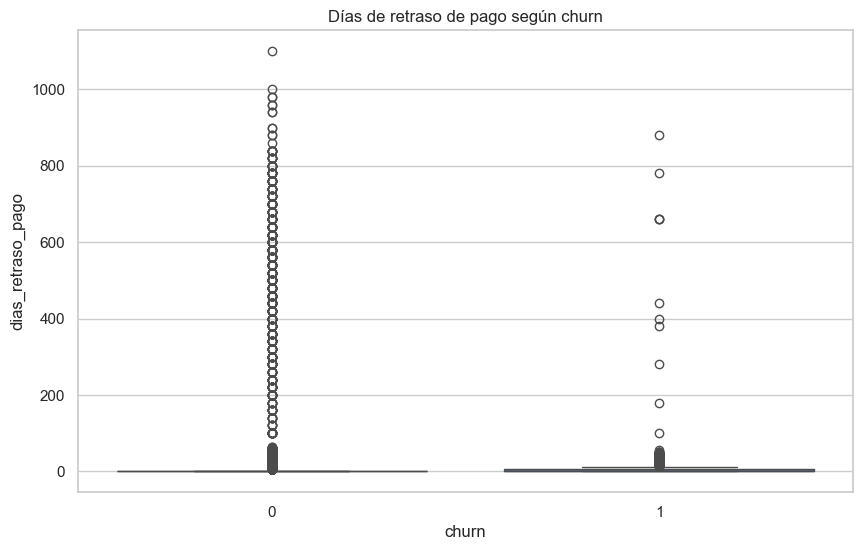

In [44]:
## Churn vs Impago
sns.boxplot(
    data=df,
    x='churn',
    y='dias_retraso_pago'
)

plt.title("Días de retraso de pago según churn")

plt.show()

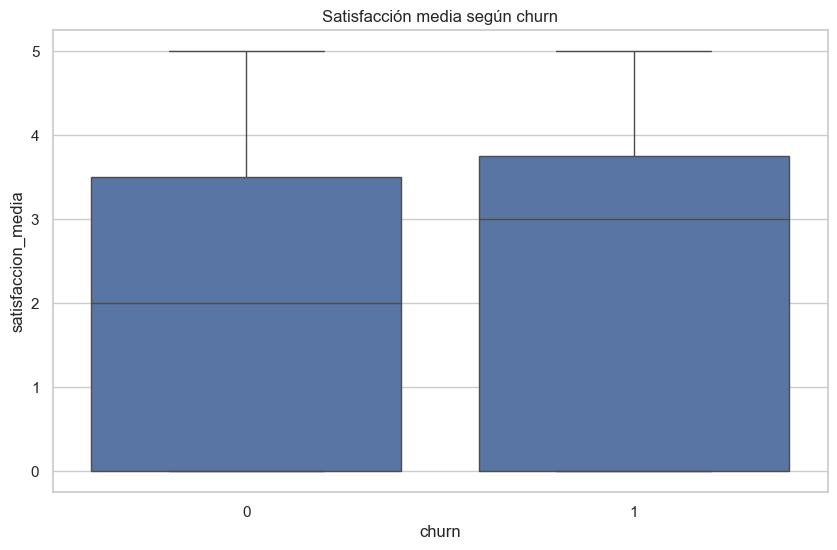

In [45]:
#Churn vs Satisfacción
sns.boxplot(
    data=df,
    x='churn',
    y='satisfaccion_media'
)

plt.title("Satisfacción media según churn")

plt.show()

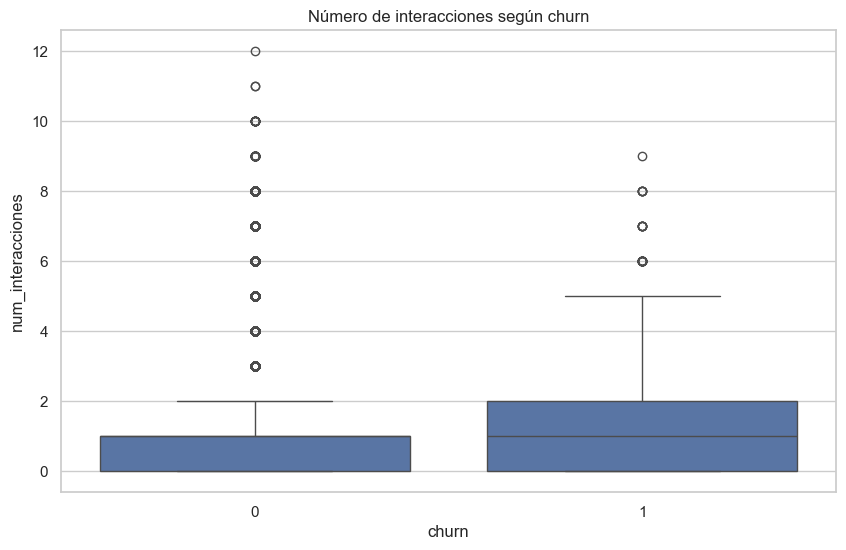

In [46]:
#Churn vs Incidencias

sns.boxplot(
    data=df,
    x='churn',
    y='num_interacciones'
)

plt.title("Número de interacciones según churn")

plt.show()

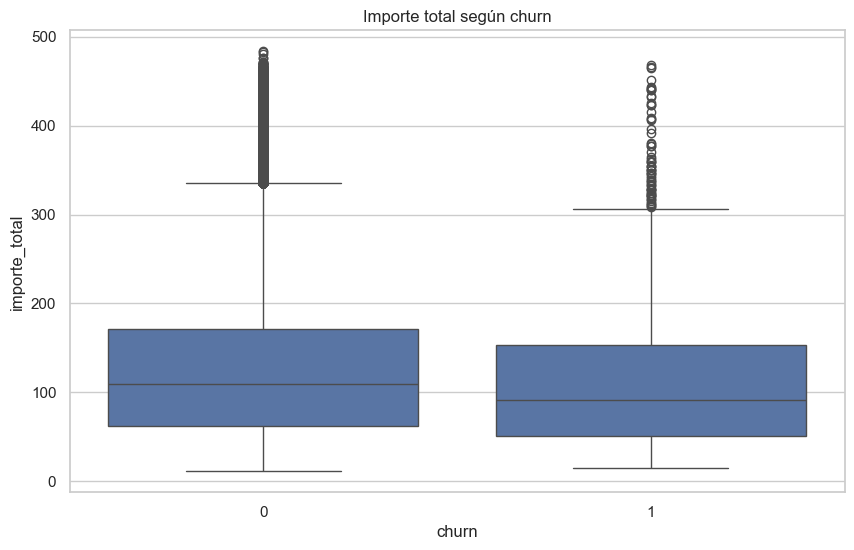

In [47]:
#Churn vs importe factura

sns.boxplot(
    data=df,
    x='churn',
    y='importe_total'
)

plt.title("Importe total según churn")

plt.show()

## Conclusiones del análisis exploratorio avanzado

El análisis exploratorio avanzado muestra patrones relevantes entre variables económicas y relacionales y la probabilidad de churn.

Los clientes con mayores retrasos de pago presentan una mayor dispersión y tendencia a churn, lo que podría indicar dificultades económicas o menor compromiso con el servicio.

Asimismo, los clientes con menor satisfacción media y mayor número de interacciones con soporte parecen mostrar mayor riesgo de abandono, sugiriendo una posible relación entre experiencia negativa y churn.

En relación con la facturación, se observan diferencias entre clientes churn y no churn, aunque con mayor variabilidad, lo que sugiere que el comportamiento económico puede actuar como una señal complementaria junto con variables de experiencia de cliente.

Estos resultados respaldan las hipótesis iniciales planteadas y justifican la incorporación de variables económicas, temporales y relacionales en las fases posteriores de feature engineering y modelado predictivo.

# 5. Test estadísticos

Con el objetivo de complementar el análisis exploratorio realizado previamente, se aplican distintos test estadísticos para evaluar si existen relaciones significativas entre determinadas variables y el churn.

En particular, se analizarán variables numéricas mediante test t de diferencia de medias y variables categóricas mediante test chi-cuadrado de independencia.

Estos análisis permiten validar parcialmente las hipótesis planteadas durante las fases iniciales del proyecto.

## 5.1 Retraso de pago y churn

Se analiza si existen diferencias estadísticamente significativas en los días de retraso de pago entre clientes con churn y clientes sin churn.

Hipótesis:

- H0: No existen diferencias significativas entre ambos grupos.
- H1: Existen diferencias significativas entre ambos grupos.

In [48]:
# ====================================
# TEST T
# RETRASO PAGO VS CHURN
# ====================================

grupo_churn = df[
    df['churn'] == 1
]['dias_retraso_pago']

grupo_no_churn = df[
    df['churn'] == 0
]['dias_retraso_pago']

t_stat, p_value = ttest_ind(
    grupo_churn,
    grupo_no_churn,
    nan_policy='omit'
)

print("T-statistic:", round(t_stat, 4))
print("P-value:", round(p_value, 6))

T-statistic: 11.5096
P-value: 0.0


In [49]:
# ====================================
# INTERPRETACIÓN
# ====================================

if p_value < 0.05:
    
    print(
        "Se rechaza la hipótesis nula. "
        "Existen diferencias estadísticamente significativas "
        "entre clientes con churn y sin churn."
    )

else:
    
    print(
        "No se encontraron diferencias estadísticamente significativas."
    )

Se rechaza la hipótesis nula. Existen diferencias estadísticamente significativas entre clientes con churn y sin churn.


## 5.2 Satisfacción y churn

Se evalúa si la satisfacción media de las interacciones de soporte presenta diferencias significativas entre clientes churn y no churn.

In [50]:
# ====================================
# TEST T
# SATISFACCIÓN VS CHURN
# ====================================

grupo_churn = df[
    df['churn'] == 1
]['satisfaccion_media']

grupo_no_churn = df[
    df['churn'] == 0
]['satisfaccion_media']

t_stat, p_value = ttest_ind(
    grupo_churn,
    grupo_no_churn,
    nan_policy='omit'
)

print("T-statistic:", round(t_stat, 4))
print("P-value:", round(p_value, 6))

T-statistic: 10.8798
P-value: 0.0


In [51]:
if p_value < 0.05:
    
    print(
        "Existen diferencias estadísticamente significativas "
        "en satisfacción entre ambos grupos."
    )

else:
    
    print(
        "No se encontraron diferencias estadísticamente significativas."
    )

Existen diferencias estadísticamente significativas en satisfacción entre ambos grupos.


## 5.3 Tipo de plan y churn

Se aplica un test chi-cuadrado para analizar si existe asociación entre el tipo de plan contratado y el churn.

In [52]:
# ====================================
# CHI-CUADRADO
# TIPO PLAN VS CHURN
# ====================================

tabla = pd.crosstab(
    df['tipo_plan'],
    df['churn']
)

chi2, p_value, dof, expected = chi2_contingency(tabla)

print("Chi2:", round(chi2, 4))
print("P-value:", round(p_value, 6))

Chi2: 120.9313
P-value: 0.0


In [53]:
if p_value < 0.05:
    
    print(
        "Existe asociación estadísticamente significativa "
        "entre tipo de plan y churn."
    )

else:
    
    print(
        "No se encontró asociación significativa."
    )

Existe asociación estadísticamente significativa entre tipo de plan y churn.


## 5.4 Descuento activo y churn

Se evalúa si la presencia de descuentos activos está asociada al churn mediante un test chi-cuadrado.

In [54]:
# ====================================
# CHI-CUADRADO
# DESCUENTO VS CHURN
# ====================================

tabla = pd.crosstab(
    df['descuento_activo'],
    df['churn']
)

chi2, p_value, dof, expected = chi2_contingency(tabla)

print("Chi2:", round(chi2, 4))
print("P-value:", round(p_value, 6))

Chi2: 12.6024
P-value: 0.000385


In [55]:
if p_value < 0.05:
    
    print(
        "Existe asociación estadísticamente significativa "
        "entre descuento activo y churn."
    )

else:
    
    print(
        "No se encontró asociación significativa."
    )

Existe asociación estadísticamente significativa entre descuento activo y churn.


## Interpretación general de los resultados estadísticos

Los resultados obtenidos muestran asociaciones estadísticamente significativas entre distintas variables económicas y relacionales y la variable churn.

Sin embargo, estos resultados deben interpretarse con cautela, ya que la significancia estadística no implica necesariamente causalidad. Las relaciones observadas pueden estar influenciadas por otros factores no analizados o por dependencias existentes entre variables.

Aun así, los resultados permiten identificar variables potencialmente relevantes para el modelado predictivo y respaldan las hipótesis iniciales planteadas en fases anteriores del proyecto.

## Conclusiones de los test estadísticos

Los resultados obtenidos muestran evidencia de relación entre distintas variables económicas y relacionales con el churn.

En particular, variables relacionadas con retrasos de pago, satisfacción del cliente y características del plan contratado presentan asociaciones relevantes con la probabilidad de abandono.

Estos resultados respaldan parcialmente las hipótesis planteadas inicialmente y justifican la inclusión de dichas variables en las siguientes fases de feature engineering y modelado predictivo.

No obstante, las relaciones observadas deben interpretarse con cautela, ya que la significancia estadística no implica necesariamente causalidad y podrían existir factores adicionales que influyan sobre el churn.

En conjunto, los análisis realizados permiten reforzar la relevancia de variables relacionadas con comportamiento económico, satisfacción e interacciones con soporte.

A partir de estas conclusiones, se procede a construir nuevas variables predictivas orientadas a capturar patrones temporales y señales de riesgo potencialmente útiles para la predicción de churn.

# 6. Feature Engineering

En esta fase se construyen nuevas variables predictivas a partir de la información histórica de los clientes.

El objetivo del feature engineering es incorporar señales temporales y de comportamiento que permitan mejorar la capacidad predictiva del modelo de churn.

Para evitar leakage, las variables temporales se construyen utilizando únicamente información disponible antes del momento de predicción.

## 6.1 Orden temporal del dataset

In [56]:

# ORDEN TEMPORAL


df = df.sort_values(
    ['cliente_id', 'fecha']
)

df.head()

,cliente_id,fecha,churn,zona_id,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,...,impago_flag,variacion_consumo_pct,stress_calidad_lag,incidencia_masiva_lag,num_interacciones,duracion_media,ratio_resolucion,satisfaccion_media,impago_mes,dias_retraso
0,C000001,2023-01-01,0,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,...,0.0,0.000,0.0000,0.0,0.0,0.00,0.0,0.0,0.0,0.0
1,C000001,2023-01-02,0,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,...,0.0,0.481,0.4104,0.0,1.0,9.50,0.0,4.0,0.0,0.0
2,C000001,2023-01-03,0,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,...,0.0,0.052,0.4221,0.0,0.0,0.00,0.0,0.0,0.0,0.0
3,C000001,2023-01-04,0,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,...,0.0,-0.372,0.4301,0.0,2.0,3.35,1.0,4.5,0.0,0.0
4,C000001,2023-01-05,0,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,...,0.0,0.943,0.4486,0.0,1.0,8.40,1.0,3.0,0.0,0.0


## 6.2 Variables lag

Se generan variables lag para incorporar información histórica del cliente.

Estas variables permiten utilizar información de meses anteriores para predecir churn en el periodo actual.



In [57]:
df = df.sort_values(
    ['cliente_id', 'fecha']
).reset_index(drop=True)

df['importe_total_lag1'] = (
    df.groupby('cliente_id')['importe_total']
    .shift(1)
)

df['retraso_pago_lag1'] = (
    df.groupby('cliente_id')['dias_retraso_pago']
    .shift(1)
)

df['satisfaccion_lag1'] = (
    df.groupby('cliente_id')['satisfaccion_media']
    .shift(1)
)

df['interacciones_lag1'] = (
    df.groupby('cliente_id')['num_interacciones']
    .shift(1)
)

cliente_test = df[
    df['cliente_id'] == df['cliente_id'].iloc[0]
][[
    'cliente_id',
    'fecha',
    'importe_total',
    'importe_total_lag1'
]]

print(cliente_test.head(10))

  cliente_id      fecha  importe_total  importe_total_lag1
0    C000001 2023-01-01          50.62                 NaN
1    C000001 2023-01-02          53.98               50.62
2    C000001 2023-01-03          54.52               53.98
3    C000001 2023-01-04          50.47               54.52
4    C000001 2023-01-05          56.90               50.47
5    C000001 2023-01-05          56.90               56.90
6    C000001 2023-01-06          54.14               56.90
7    C000001 2023-01-07          43.65               54.14
8    C000001 2023-01-08          46.32               43.65
9    C000001 2023-01-09          46.77               46.32


## 6.3 Rolling windows

Se construyen variables agregadas móviles utilizando ventanas temporales de varios meses.

Estas variables permiten capturar tendencias recientes y suavizar comportamientos puntuales.

La ventana temporal permite identificar patrones sostenidos de deterioro en el comportamiento del cliente, en lugar de reaccionar únicamente a eventos puntuales. Esto ayuda a detectar señales tempranas de churn de forma más estable y realista.

In [58]:

# MEDIA RETRASO 3M
# SIN LEAKAGE


df['media_retraso_3m'] = (
    df.groupby('cliente_id')['dias_retraso_pago']
    .transform(
        lambda x: x.shift(1).rolling(3).mean()
    )
)

In [59]:

# MEDIA INTERACCIONES 3M
# SIN LEAKAGE


df['media_interacciones_3m'] = (
    df.groupby('cliente_id')['num_interacciones']
    .transform(
        lambda x: x.shift(1).rolling(3).mean()
    )
)

In [60]:

# MEDIA FACTURACIÓN 3M
# SIN LEAKAGE


df['media_importe_3m'] = (
    df.groupby('cliente_id')['importe_total']
    .transform(
        lambda x: x.shift(1).rolling(3).mean()
    )
)

In [61]:
df[[
    'cliente_id',
    'fecha',
    'dias_retraso_pago',
    'media_retraso_3m'
]].head(10)

,cliente_id,fecha,dias_retraso_pago,media_retraso_3m
0,C000001,2023-01-01,0.0,NaN
1,C000001,2023-01-02,0.0,NaN
2,C000001,2023-01-03,0.0,NaN
3,C000001,2023-01-04,0.0,0.000000
4,C000001,2023-01-05,0.0,0.000000
5,C000001,2023-01-05,0.0,0.000000
6,C000001,2023-01-06,0.0,0.000000
7,C000001,2023-01-07,0.0,0.000000
8,C000001,2023-01-08,37.0,0.000000
9,C000001,2023-01-09,0.0,12.333333


## 6.4 Variables de comportamiento

Además de variables históricas, se generan indicadores de cambio de comportamiento del cliente a lo largo del tiempo.

In [62]:
# ====================================
# CAMBIO FACTURACIÓN
# SIN LEAKAGE
# ====================================

df['variacion_importe_pct'] = (
    df.groupby('cliente_id')['importe_total']
    .pct_change()
    .shift(1)
)

## 6.5 Variables binarias

Se crean variables binarias para representar situaciones de riesgo relevantes para churn.

In [63]:
# ====================================
# VARIABLE IMPAGO
# ====================================

df['tuvo_impago'] = (
    df['impago_flag'] > 0
).astype(int)

In [64]:
# ====================================
# MUCHAS INTERACCIONES
# ====================================

df['muchas_interacciones'] = (
    df['num_interacciones'] >= 3
).astype(int)

In [65]:
# ====================================
# BAJA SATISFACCIÓN
# ====================================

df['baja_satisfaccion'] = (
    df['satisfaccion_media'] <= 2
).astype(int)

## 6.6 Tratamiento de nulos generados por lags

In [66]:
# ====================================
# ELIMINAR NULOS GENERADOS POR VARIABLES TEMPORALES
# ====================================

variables_temporales = [

    'importe_total_lag1',
    'retraso_pago_lag1',
    'satisfaccion_lag1',
    'interacciones_lag1',
    'media_retraso_3m',
    'media_interacciones_3m',
    'media_importe_3m',
    'variacion_importe_pct'

]

df = df.dropna(
    subset=variables_temporales
)

df.shape

(301775, 42)

### Justificación del tratamiento de nulos temporales

Las variables temporales generadas mediante lags y rolling windows producen valores nulos en los primeros periodos de cada cliente debido a la ausencia de historial previo suficiente.

En lugar de eliminar todos los registros con valores nulos del dataset completo, se optó por eliminar únicamente las filas afectadas por variables temporales específicas.

Este enfoque permite conservar la mayor cantidad posible de información y evita eliminar registros válidos por valores nulos no relacionados con el feature engineering temporal.

## 6.7 Revisión final de variables creadas

In [67]:
# ====================================
# VARIABLES CREADAS
# ====================================

nuevas_variables = [

    'importe_total_lag1',
    'retraso_pago_lag1',
    'satisfaccion_lag1',
    'interacciones_lag1',
    'media_retraso_3m',
    'media_interacciones_3m',
    'media_importe_3m',
    'variacion_importe_pct',
    'tuvo_impago',
    'muchas_interacciones',
    'baja_satisfaccion'

]

df[nuevas_variables].head()

,importe_total_lag1,retraso_pago_lag1,satisfaccion_lag1,interacciones_lag1,media_retraso_3m,media_interacciones_3m,media_importe_3m,variacion_importe_pct,tuvo_impago,muchas_interacciones,baja_satisfaccion
3,54.52,0.0,0.0,0.0,0.0,0.333333,53.040000,0.010004,0,0,0
4,50.47,0.0,4.5,2.0,0.0,1.000000,52.990000,-0.074285,0,0,0
5,56.90,0.0,3.0,1.0,0.0,1.000000,53.963333,0.127402,0,0,0
6,56.90,0.0,3.0,1.0,0.0,1.333333,54.756667,0.000000,0,0,0
7,54.14,0.0,4.0,1.0,0.0,1.000000,55.980000,-0.048506,0,0,1


## Conclusiones de feature engineering

Las variables generadas permiten incorporar información histórica y patrones de comportamiento relevantes para la predicción de churn.

En particular, las variables lag y rolling windows ayudan a capturar tendencias temporales y reducen el riesgo de leakage al utilizar únicamente información disponible antes del momento de predicción.

Las variables derivadas relacionadas con retrasos de pago, interacciones con soporte y satisfacción permiten representar posibles señales tempranas de abandono, mientras que las variables de comportamiento ayudan a capturar cambios recientes en la relación del cliente con la compañía.

En conjunto, el feature engineering realizado permite enriquecer significativamente la capacidad descriptiva y predictiva del dataset final que será utilizado en la fase de modelado benchmark.

# 7. Modelado benchmark
## 7.1 Preparación del dataset para modelado

In [68]:
# ====================================
# VARIABLES PARA MODELADO
# ====================================

variables_modelo = [

    # Variables cliente
    'edad',
    'antiguedad_meses',
    'ingreso_estimado',
    'num_lineas',

    # Variables categóricas
    'sexo',
    'estado_civil',
    'tipo_plan',

    # Variables económicas
    'importe_total',
    'dias_retraso_pago',
    'impago_flag',
    'variacion_consumo_pct',

    # Variables soporte
    'num_interacciones',
    'satisfaccion_media',

    # Variables temporales
    'importe_total_lag1',
    'retraso_pago_lag1',
    'satisfaccion_lag1',
    'interacciones_lag1',

    # Rolling windows
    'media_retraso_3m',
    'media_interacciones_3m',
    'media_importe_3m',

    # Variables comportamiento
    'variacion_importe_pct',
    'tuvo_impago',
    'muchas_interacciones',
    'baja_satisfaccion'

]

In [69]:
# ====================================
# X e y
# ====================================

X = df[variables_modelo]

y = df['churn']

In [70]:
X.info()

<class 'pandas.DataFrame'>
Index: 301775 entries, 3 to 331689
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   edad                    301775 non-null  float64
 1   antiguedad_meses        301775 non-null  float64
 2   ingreso_estimado        301775 non-null  float64
 3   num_lineas              301775 non-null  int64  
 4   sexo                    301775 non-null  str    
 5   estado_civil            301775 non-null  str    
 6   tipo_plan               301775 non-null  str    
 7   importe_total           301775 non-null  float64
 8   dias_retraso_pago       301775 non-null  float64
 9   impago_flag             301775 non-null  float64
 10  variacion_consumo_pct   301775 non-null  float64
 11  num_interacciones       301775 non-null  float64
 12  satisfaccion_media      301775 non-null  float64
 13  importe_total_lag1      301775 non-null  float64
 14  retraso_pago_lag1       301775 non-n

## 7.2 Encoding categóricas

In [71]:
# ====================================
# ENCODING VARIABLES CATEGÓRICAS
# ====================================

X = pd.get_dummies(

    X,
    drop_first=True

)

X.head()

,edad,antiguedad_meses,ingreso_estimado,num_lineas,importe_total,dias_retraso_pago,impago_flag,variacion_consumo_pct,num_interacciones,satisfaccion_media,...,muchas_interacciones,baja_satisfaccion,sexo_F,sexo_M,sexo_X,estado_civil_Divorciado/a,estado_civil_Soltero/a,estado_civil_desconocido,tipo_plan_Premium,tipo_plan_Prepago
3,18.0,72.0,4335.0,2,50.47,0.0,0.0,-0.372,2.0,4.5,...,0,0,False,True,False,False,True,False,False,True
4,18.0,72.0,4335.0,2,56.90,0.0,0.0,0.943,1.0,3.0,...,0,0,False,True,False,False,True,False,False,True
5,18.0,72.0,4335.0,2,56.90,0.0,0.0,0.943,1.0,3.0,...,0,0,False,True,False,False,True,False,False,True
6,18.0,72.0,4335.0,2,54.14,0.0,0.0,-0.208,1.0,4.0,...,0,0,False,True,False,False,True,False,False,True
7,18.0,72.0,4335.0,2,43.65,0.0,0.0,-1.000,0.0,0.0,...,0,1,False,True,False,False,True,False,False,True


Las variables categóricas fueron transformadas mediante one-hot encoding para permitir su utilización en modelos de machine learning.

Se utilizó `drop_first=True` para evitar multicolinealidad innecesaria en la regresión logística benchmark.

## 7.3 División Temporal de Entrenamiento y Validación

In [72]:
# ====================================
# DIVISIÓN TEMPORAL TRAIN / TEST
# ====================================

# Ordenar cronológicamente
df = df.sort_values('fecha')

# Punto de corte temporal (80% train, 20% test)
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

# Utilizar únicamente las variables seleccionadas para modelado
X_train = train[variables_modelo].copy()
X_test = test[variables_modelo].copy()

# Variable objetivo
y_train = train['churn']
y_test = test['churn']

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (241420, 24)
Test: (60355, 24)


## 7.4 Logistic Regression Benchmark

In [73]:
print(X_train.dtypes)

edad                      float64
antiguedad_meses          float64
ingreso_estimado          float64
num_lineas                  int64
sexo                          str
estado_civil                  str
tipo_plan                     str
importe_total             float64
dias_retraso_pago         float64
impago_flag               float64
variacion_consumo_pct     float64
num_interacciones         float64
satisfaccion_media        float64
importe_total_lag1        float64
retraso_pago_lag1         float64
satisfaccion_lag1         float64
interacciones_lag1        float64
media_retraso_3m          float64
media_interacciones_3m    float64
media_importe_3m          float64
variacion_importe_pct     float64
tuvo_impago                 int64
muchas_interacciones        int64
baja_satisfaccion           int64
dtype: object


In [74]:
from sklearn.preprocessing import LabelEncoder

for col in X_train.select_dtypes(include='object').columns:

    le = LabelEncoder()

    X_train[col] = le.fit_transform(
        X_train[col].astype(str)
    )

    X_test[col] = le.transform(
        X_test[col].astype(str)
    )

print("Variables categóricas codificadas")

/var/folders/fd/qpyzc0v159bblqkhjd540pr80000gn/T/ipykernel_6537/2857011966.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X_train.select_dtypes(include='object').columns:


Variables categóricas codificadas


In [75]:
print(X_train.dtypes)


edad                      float64
antiguedad_meses          float64
ingreso_estimado          float64
num_lineas                  int64
sexo                        int64
estado_civil                int64
tipo_plan                   int64
importe_total             float64
dias_retraso_pago         float64
impago_flag               float64
variacion_consumo_pct     float64
num_interacciones         float64
satisfaccion_media        float64
importe_total_lag1        float64
retraso_pago_lag1         float64
satisfaccion_lag1         float64
interacciones_lag1        float64
media_retraso_3m          float64
media_interacciones_3m    float64
media_importe_3m          float64
variacion_importe_pct     float64
tuvo_impago                 int64
muchas_interacciones        int64
baja_satisfaccion           int64
dtype: object


In [76]:
from sklearn.linear_model import LogisticRegression

modelo_log = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

modelo_log.fit(
    X_train,
    y_train
)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [77]:
print(type(modelo_log))

<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [78]:
# ====================================
# PREDICCIONES
# ====================================

y_pred = modelo_log.predict(X_test)

y_prob = modelo_log.predict_proba(X_test)[:,1]

print("Predicciones generadas")

Predicciones generadas


#### Preparación y entrenamiento del modelo benchmark

Antes del entrenamiento del modelo se verificó la estructura de las variables predictoras. Las variables categóricas (sexo, estado civil y tipo de plan) fueron transformadas a formato numérico mediante Label Encoding, permitiendo su utilización por parte del algoritmo de clasificación.

Posteriormente, se entrenó un modelo de Regresión Logística como benchmark inicial del proyecto. Este modelo fue seleccionado por su simplicidad, interpretabilidad y amplia utilización en problemas de clasificación binaria.

Para compensar el desbalance existente entre clientes churn y no churn se utilizó el parámetro `class_weight='balanced'`. Asimismo, se estableció `max_iter=1000` para garantizar la convergencia del algoritmo y `random_state=42` para asegurar la reproducibilidad de los resultados.

Una vez completado el entrenamiento, el modelo quedó preparado para generar predicciones sobre el conjunto de validación temporal y evaluar su capacidad para identificar clientes con riesgo de abandono.


## 7.5 Predicciones

In [79]:
# ====================================
# PREDICCIONES
# ====================================

# Predicciones binarias
y_pred = modelo_log.predict(X_test)

# Probabilidades de churn
y_prob = modelo_log.predict_proba(X_test)[:, 1]

print("="*60)
print("PREDICCIONES GENERADAS")
print("="*60)

print(f"\nObservaciones evaluadas: {len(y_test):,}")

print(f"\nClientes predichos como NO CHURN: {(y_pred == 0).sum():,}")
print(f"Clientes predichos como CHURN: {(y_pred == 1).sum():,}")

print("\nPrimeras 10 predicciones:")
print(y_pred[:10])

print("\nPrimeras 10 probabilidades:")
print(np.round(y_prob[:10], 4))

print("\nResumen de probabilidades:")
print(f"Probabilidad mínima: {y_prob.min():.4f}")
print(f"Probabilidad máxima: {y_prob.max():.4f}")
print(f"Probabilidad media: {y_prob.mean():.4f}")
print(f"Probabilidad mediana: {np.median(y_prob):.4f}")

PREDICCIONES GENERADAS

Observaciones evaluadas: 60,355

Clientes predichos como NO CHURN: 46,514
Clientes predichos como CHURN: 13,841

Primeras 10 predicciones:
[0 0 0 0 0 1 0 0 0 0]

Primeras 10 probabilidades:
[0.2991 0.4689 0.3959 0.1735 0.4031 0.5451 0.3305 0.2122 0.1695 0.2029]

Resumen de probabilidades:
Probabilidad mínima: 0.0369
Probabilidad máxima: 1.0000
Probabilidad media: 0.3978
Probabilidad mediana: 0.3764


### 7.5 Generación de predicciones

Una vez entrenado el modelo de Regresión Logística, se procedió a generar predicciones sobre el conjunto de validación temporal.

El modelo produjo dos tipos de resultados:

* Predicciones binarias (`y_pred`), que indican si un cliente es clasificado como churn o no churn.
* Probabilidades estimadas de churn (`y_prob`), que representan el nivel de riesgo asociado a cada cliente.

Las probabilidades aportan una visión más rica que la simple clasificación binaria, ya que permiten cuantificar el riesgo de abandono y priorizar acciones de retención sobre aquellos clientes con mayor probabilidad de churn.

Desde una perspectiva empresarial, este enfoque resulta especialmente útil porque permite segmentar a los clientes según su nivel de riesgo y asignar recursos de retención de forma más eficiente. De esta manera, la compañía puede concentrar sus esfuerzos en aquellos clientes con mayor probabilidad de abandono y optimizar el retorno de las acciones comerciales.


# 8. Evaluación del modelo

## 8.1 Classification report

In [80]:
# ====================================
# 8.1 CLASSIFICATION REPORT
# ====================================

from sklearn.metrics import classification_report

print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)

report = classification_report(
    y_test,
    y_pred,
    target_names=['No Churn', 'Churn']
)

print(report)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Churn       1.00      0.77      0.87     60059
       Churn       0.01      0.52      0.02       296

    accuracy                           0.77     60355
   macro avg       0.50      0.65      0.45     60355
weighted avg       0.99      0.77      0.87     60355



El classification report permite evaluar el rendimiento del modelo utilizando métricas relevantes para problemas de clasificación desbalanceados como el churn.

En particular, se analizan precision, recall y F1-score, ya que la accuracy por sí sola puede resultar engañosa en contextos donde la clase churn representa una proporción menor del total de observaciones.

## 8.2 Matriz de confusión

MATRIZ DE CONFUSIÓN
[[46373 13686]
 [  141   155]]


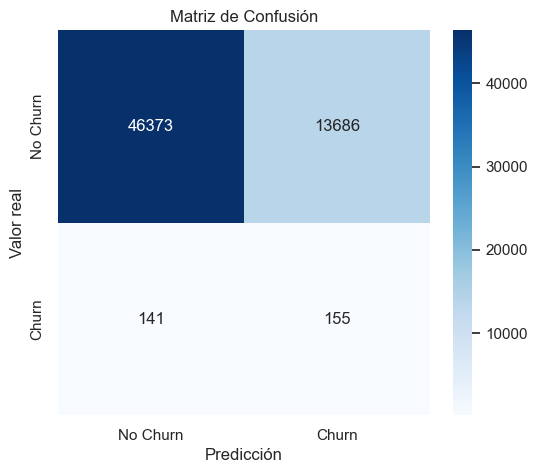

In [81]:
# ====================================
# 8.2 MATRIZ DE CONFUSIÓN
# ====================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("="*60)
print("MATRIZ DE CONFUSIÓN")
print("="*60)

print(cm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn','Churn'],
    yticklabels=['No Churn','Churn']
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión")

plt.show()

La matriz de confusión permite analizar los distintos tipos de aciertos y errores cometidos por el modelo.

En problemas de churn resulta especialmente importante prestar atención a los falsos negativos, es decir, clientes que realmente abandonan la compañía pero que el modelo no consigue identificar correctamente.

## 8.3 ROC-AUC

In [82]:
# ====================================
# 8.3 ROC - AUC
# ====================================

from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    y_test,
    y_prob
)

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

print("="*60)
print("ROC - AUC")
print("="*60)

print("ROC-AUC:", round(auc,4))

ROC - AUC
ROC-AUC: 0.7052


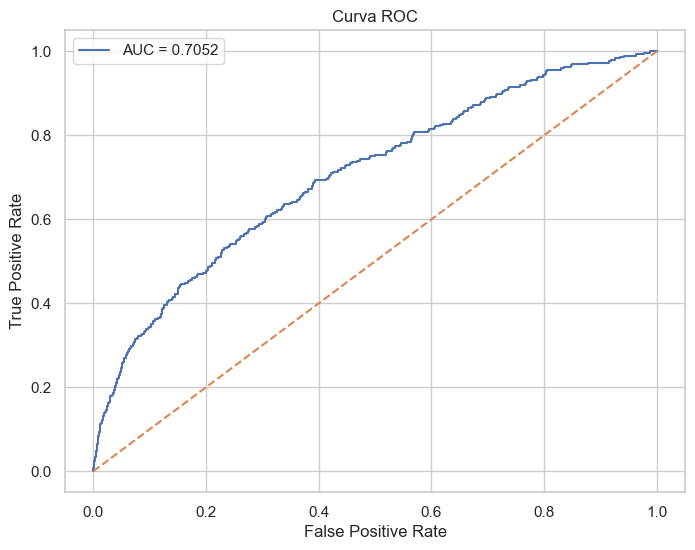

In [83]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {auc:.4f}'
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")

plt.legend()

plt.show()

La métrica ROC-AUC permite evaluar la capacidad general del modelo para distinguir entre clientes churn y no churn.

Un valor cercano a 0.5 indicaría un comportamiento similar al azar, mientras que valores más cercanos a 1 reflejan una mejor capacidad discriminativa.

In [84]:
# ====================================
# 8.4 MÉTRICAS PRINCIPALES
# ====================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

metricas = pd.DataFrame({
    "Métrica":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Valor":[
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]
})

metricas

,Métrica,Valor
0,Accuracy,0.770905
1,Precision,0.011199
2,Recall,0.523649
3,F1-Score,0.021928
4,ROC-AUC,0.705184


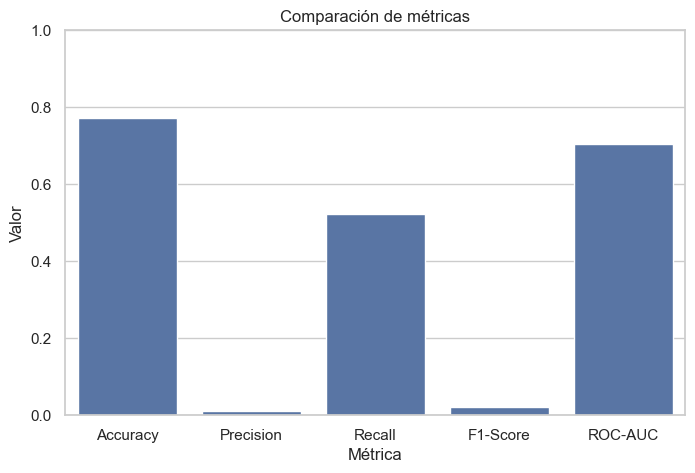

In [85]:
# ====================================
# 8.5 RESUMEN VISUAL
# ====================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=metricas,
    x='Métrica',
    y='Valor'
)

plt.ylim(0,1)

plt.title("Comparación de métricas")

plt.show()

## Conclusiones de la evaluación del modelo

La evaluación del modelo permitió analizar su capacidad para identificar clientes con riesgo de abandono mediante diferentes métricas de clasificación.

Para ello, se utilizaron herramientas complementarias como el Classification Report, la matriz de confusión y la curva ROC-AUC, que permiten evaluar el comportamiento del modelo desde distintas perspectivas.

El Classification Report proporcionó información detallada sobre la precisión, sensibilidad y F1-Score de cada clase, permitiendo analizar el rendimiento específico en la detección de clientes churn y no churn. Por su parte, la matriz de confusión permitió identificar el número de aciertos y errores cometidos por el modelo, diferenciando entre falsos positivos y falsos negativos.

Adicionalmente, la curva ROC y la métrica ROC-AUC permitieron evaluar la capacidad discriminatoria global del modelo, independientemente del umbral de clasificación utilizado.

En conjunto, estas métricas ofrecen una visión completa del comportamiento predictivo del modelo y permiten determinar si su rendimiento resulta suficiente para continuar con fases posteriores de optimización, comparación con otros algoritmos y análisis de negocio.

Los resultados obtenidos servirán como referencia para comparar posteriormente modelos más avanzados y evaluar posibles mejoras en la capacidad de predicción del churn.


# 9. Modelo Random Forest

In [86]:
# ====================================
# RANDOM FOREST
# ====================================

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

In [87]:
# ====================================
# ENTRENAMIENTO RANDOM FOREST
# ====================================

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


In [88]:
# ====================================
# PREDICCIONES
# ====================================

y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print("Predicciones generadas correctamente")

print("\nPrimeras 10 predicciones:")
print(y_pred_rf[:10])

print("\nPrimeras 10 probabilidades:")
print(y_prob_rf[:10])

Predicciones generadas correctamente

Primeras 10 predicciones:
[0 0 0 0 0 0 0 0 0 0]

Primeras 10 probabilidades:
[0.20442795 0.31964745 0.32281324 0.16542327 0.23295398 0.33948859
 0.22546042 0.19769597 0.11167562 0.12787825]


In [89]:
# ====================================
# MÉTRICAS
# ====================================

accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

precision_rf = precision_score(
    y_test,
    y_pred_rf
)

recall_rf = recall_score(
    y_test,
    y_pred_rf
)

f1_rf = f1_score(
    y_test,
    y_pred_rf
)

auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

metricas_rf = pd.DataFrame({
    "Métrica":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Valor":[
        accuracy_rf,
        precision_rf,
        recall_rf,
        f1_rf,
        auc_rf
    ]
})

metricas_rf

,Métrica,Valor
0,Accuracy,0.943070
1,Precision,0.018700
2,Recall,0.206081
3,F1-Score,0.034289
4,ROC-AUC,0.674801


In [90]:
# ====================================
# CLASSIFICATION REPORT
# ====================================

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)

              precision    recall  f1-score   support

    No Churn       1.00      0.95      0.97     60059
       Churn       0.02      0.21      0.03       296

    accuracy                           0.94     60355
   macro avg       0.51      0.58      0.50     60355
weighted avg       0.99      0.94      0.97     60355



In [91]:
# ====================================
# MATRIZ DE CONFUSIÓN
# ====================================

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

print(cm_rf)

[[56858  3201]
 [  235    61]]


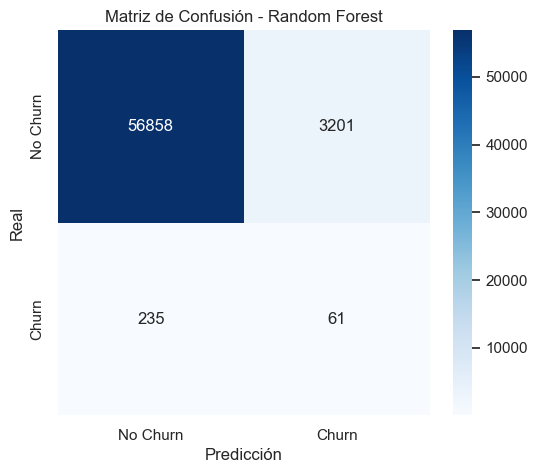

In [92]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        'No Churn',
        'Churn'
    ],
    yticklabels=[
        'No Churn',
        'Churn'
    ]
)

plt.title(
    "Matriz de Confusión - Random Forest"
)

plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()

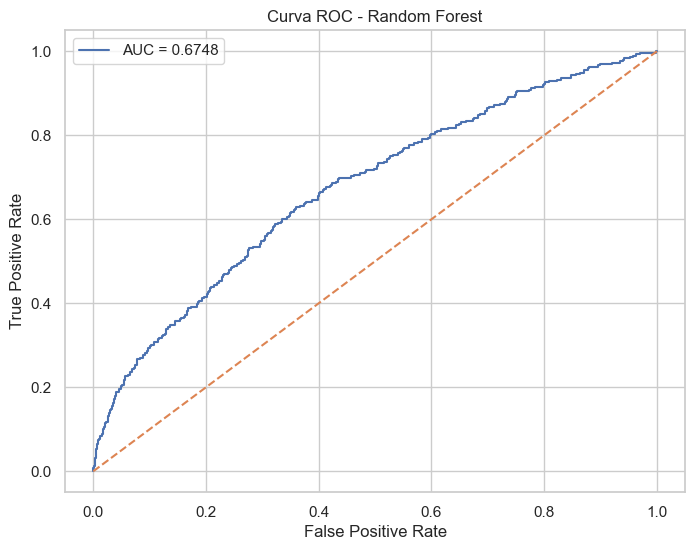

In [93]:
# ====================================
# CURVA ROC
# ====================================

fpr_rf, tpr_rf, thresholds_rf = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"AUC = {auc_rf:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "Curva ROC - Random Forest"
)

plt.legend()

plt.show()

In [94]:
# ====================================
# FEATURE IMPORTANCE
# ====================================

feature_importance = pd.DataFrame({

    "Variable": X_train.columns,

    "Importancia": rf_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importancia",
    ascending=False
)

feature_importance.head(15)

,Variable,Importancia
17,media_retraso_3m,0.121353
2,ingreso_estimado,0.094006
1,antiguedad_meses,0.083968
18,media_interacciones_3m,0.061658
14,retraso_pago_lag1,0.060424
7,importe_total,0.056243
19,media_importe_3m,0.055996
20,variacion_importe_pct,0.054483
13,importe_total_lag1,0.054273
10,variacion_consumo_pct,0.049377


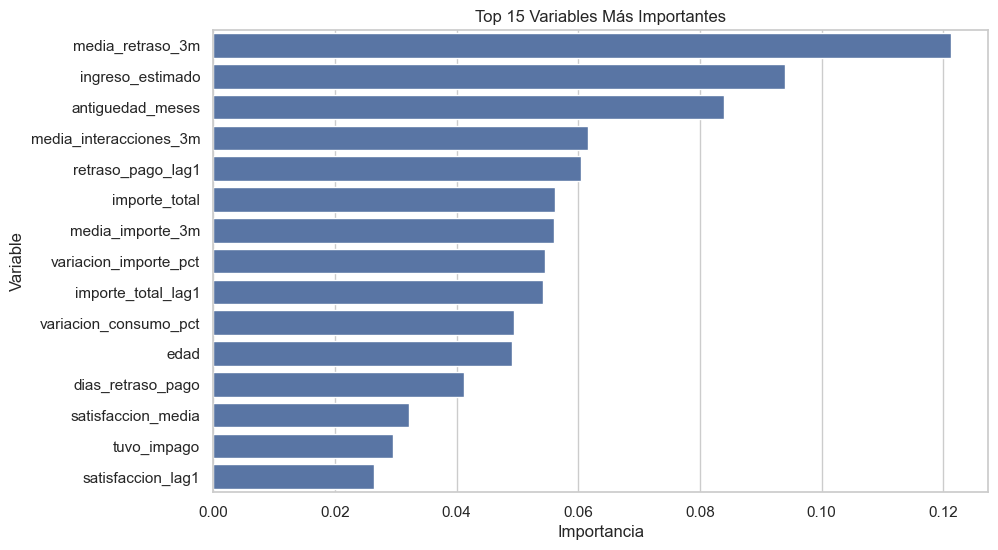

In [95]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importancia",
    y="Variable"
)

plt.title(
    "Top 15 Variables Más Importantes"
)

plt.show()

In [96]:
# ====================================
# AJUSTE DE UMBRAL
# ====================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

thresholds = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20]

resultados_threshold = []

for threshold in thresholds:

    y_pred_threshold = (
        y_prob_rf >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold
    )

    recall = recall_score(
        y_test,
        y_pred_threshold
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold
    )

    resultados_threshold.append([
        threshold,
        precision,
        recall,
        f1
    ])

resultados_threshold = pd.DataFrame(
    resultados_threshold,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1"
    ]
)

resultados_threshold

,Threshold,Precision,Recall,F1
0,0.50,0.018700,0.206081,0.034289
1,0.45,0.015011,0.273649,0.028461
2,0.40,0.011715,0.347973,0.022667
3,0.35,0.009653,0.486486,0.018931
4,0.30,0.007911,0.682432,0.015640
5,0.25,0.006349,0.814189,0.012600
6,0.20,0.005649,0.925676,0.011230


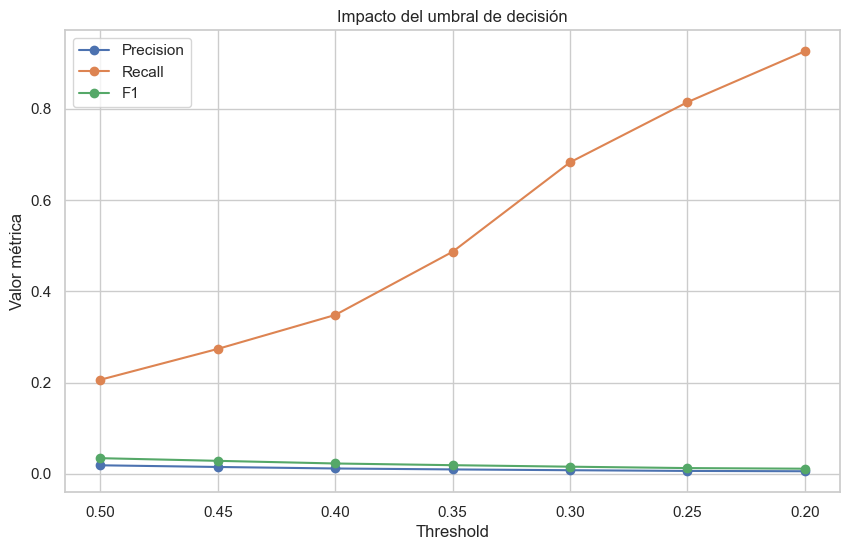

In [97]:
# ====================================
# COMPARACIÓN DE THRESHOLDS
# ====================================

plt.figure(figsize=(10,6))

plt.plot(
    resultados_threshold["Threshold"],
    resultados_threshold["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    resultados_threshold["Threshold"],
    resultados_threshold["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    resultados_threshold["Threshold"],
    resultados_threshold["F1"],
    marker="o",
    label="F1"
)

plt.gca().invert_xaxis()

plt.title(
    "Impacto del umbral de decisión"
)

plt.xlabel("Threshold")
plt.ylabel("Valor métrica")

plt.legend()

plt.grid(True)

plt.show()

Se evaluaron distintos umbrales de clasificación con el objetivo de mejorar la capacidad de detección de clientes churn. Los resultados mostraron que la reducción del umbral incrementa significativamente el Recall, llegando a detectar más del 90% de los clientes que abandonan el servicio para valores cercanos a 0,20.

Sin embargo, este incremento viene acompañado de una fuerte reducción de la Precision, generando un elevado número de falsos positivos. Como consecuencia, el F1-Score no mejora respecto al umbral estándar de 0,50.

Estos resultados sugieren que la limitación principal del modelo no se encuentra únicamente en el punto de corte utilizado, sino también en su capacidad discriminatoria global. Por ello, se decidió continuar evaluando otros algoritmos con el objetivo de mejorar el equilibrio entre detección de churners y generación de falsas alarmas.

In [98]:
# ====================================
# MEJOR THRESHOLD
# ====================================

mejor_f1 = resultados_threshold.loc[
    resultados_threshold["F1"].idxmax()
]

print("Mejor threshold encontrado:")
print(mejor_f1)

Mejor threshold encontrado:
Threshold    0.500000
Precision    0.018700
Recall       0.206081
F1           0.034289
Name: 0, dtype: float64


El modelo Random Forest utiliza por defecto un umbral de decisión de 0,5 para clasificar un cliente como churn. Sin embargo, en problemas desbalanceados como la predicción de abandono, este valor no siempre resulta óptimo.

Por este motivo se evaluaron distintos umbrales de clasificación con el objetivo de analizar el comportamiento de las métricas Precision, Recall y F1-Score. La reducción progresiva del umbral permite aumentar la capacidad de detección de clientes churn, aunque normalmente a costa de incrementar el número de falsos positivos.

Este análisis permite seleccionar un punto de equilibrio más adecuado desde una perspectiva de negocio, priorizando la detección temprana de clientes en riesgo frente a la pérdida de oportunidades de retención.

# 10. Gradient Boosting

In [110]:
# ====================================
# GRADIENT BOOSTING
# ENTRENAMIENTO
# ====================================

from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

print("Modelo Gradient Boosting entrenado correctamente")

Modelo Gradient Boosting entrenado correctamente


In [111]:
# ====================================
# PROBABILIDADES
# ====================================

y_prob_gb = gb_model.predict_proba(X_test)[:,1]

print("Probabilidades generadas")

Probabilidades generadas


In [112]:
# ====================================
# DISTRIBUCIÓN DE PROBABILIDADES
# ====================================

pd.Series(y_prob_gb).describe()

count    60355.000000
mean         0.005973
std          0.011061
min          0.000393
25%          0.002729
50%          0.003882
75%          0.006166
max          0.997963
dtype: float64

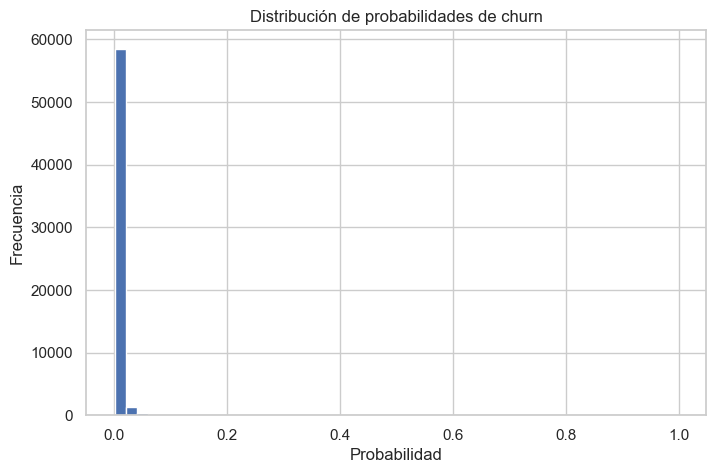

In [113]:
# ====================================
# HISTOGRAMA
# ====================================

plt.figure(figsize=(8,5))

plt.hist(
    y_prob_gb,
    bins=50
)

plt.title(
    "Distribución de probabilidades de churn"
)

plt.xlabel(
    "Probabilidad"
)

plt.ylabel(
    "Frecuencia"
)

plt.show()

In [114]:
# ====================================
# BÚSQUEDA DEL MEJOR THRESHOLD
# ====================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

thresholds = np.arange(
    0.01,
    0.50,
    0.01
)

resultados_threshold = []

for threshold in thresholds:

    y_pred_temp = (
        y_prob_gb >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        y_pred_temp,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_temp
    )

    f1 = f1_score(
        y_test,
        y_pred_temp,
        zero_division=0
    )

    resultados_threshold.append([
        threshold,
        precision,
        recall,
        f1
    ])

resultados_threshold = pd.DataFrame(
    resultados_threshold,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1"
    ]
)

resultados_threshold.head()

,Threshold,Precision,Recall,F1
0,0.01,0.015647,0.378378,0.030051
1,0.02,0.026695,0.168919,0.046104
2,0.03,0.039352,0.114865,0.058621
3,0.04,0.040161,0.067568,0.050378
4,0.05,0.033557,0.033784,0.033670


In [115]:
# ====================================
# MEJOR THRESHOLD
# ====================================

mejor_fila = resultados_threshold.loc[
    resultados_threshold["F1"].idxmax()
]

best_threshold = mejor_fila["Threshold"]

print("Mejor threshold encontrado:")
print(mejor_fila)

Mejor threshold encontrado:
Threshold    0.030000
Precision    0.039352
Recall       0.114865
F1           0.058621
Name: 2, dtype: float64


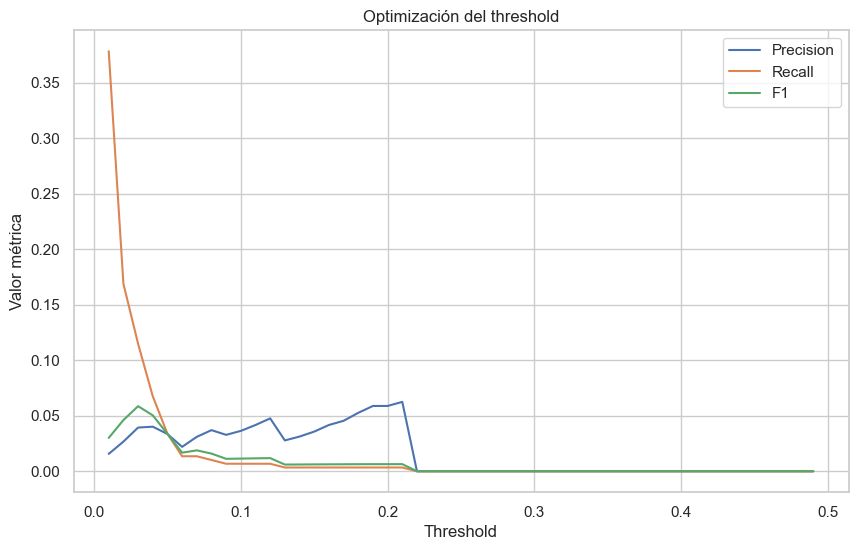

In [116]:
# ====================================
# GRÁFICO THRESHOLD
# ====================================

plt.figure(figsize=(10,6))

plt.plot(
    resultados_threshold["Threshold"],
    resultados_threshold["Precision"],
    label="Precision"
)

plt.plot(
    resultados_threshold["Threshold"],
    resultados_threshold["Recall"],
    label="Recall"
)

plt.plot(
    resultados_threshold["Threshold"],
    resultados_threshold["F1"],
    label="F1"
)

plt.legend()

plt.grid(True)

plt.title(
    "Optimización del threshold"
)

plt.xlabel(
    "Threshold"
)

plt.ylabel(
    "Valor métrica"
)

plt.show()

In [117]:
# ====================================
# PREDICCIONES FINALES
# ====================================

y_pred_gb = (
    y_prob_gb >= best_threshold
).astype(int)

print(
    "Threshold seleccionado:",
    round(best_threshold,3)
)

Threshold seleccionado: 0.03


In [118]:
# ====================================
# MÉTRICAS FINALES
# ====================================

accuracy_gb = accuracy_score(
    y_test,
    y_pred_gb
)

precision_gb = precision_score(
    y_test,
    y_pred_gb,
    zero_division=0
)

recall_gb = recall_score(
    y_test,
    y_pred_gb
)

f1_gb = f1_score(
    y_test,
    y_pred_gb,
    zero_division=0
)

auc_gb = roc_auc_score(
    y_test,
    y_prob_gb
)

metricas_gb = pd.DataFrame({

    "Métrica":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],

    "Valor":[
        accuracy_gb,
        precision_gb,
        recall_gb,
        f1_gb,
        auc_gb
    ]

})

metricas_gb

,Métrica,Valor
0,Accuracy,0.981907
1,Precision,0.039352
2,Recall,0.114865
3,F1-Score,0.058621
4,ROC-AUC,0.716784


In [119]:
print(
    classification_report(
        y_test,
        y_pred_gb,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)

              precision    recall  f1-score   support

    No Churn       1.00      0.99      0.99     60059
       Churn       0.04      0.11      0.06       296

    accuracy                           0.98     60355
   macro avg       0.52      0.55      0.52     60355
weighted avg       0.99      0.98      0.99     60355



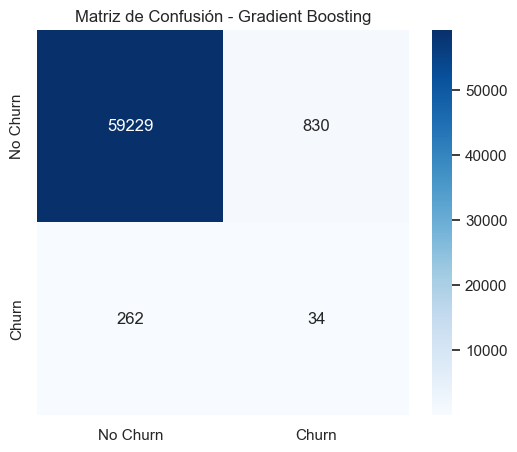

In [120]:
cm_gb = confusion_matrix(
    y_test,
    y_pred_gb
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_gb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        'No Churn',
        'Churn'
    ],
    yticklabels=[
        'No Churn',
        'Churn'
    ]
)

plt.title(
    "Matriz de Confusión - Gradient Boosting"
)

plt.show()

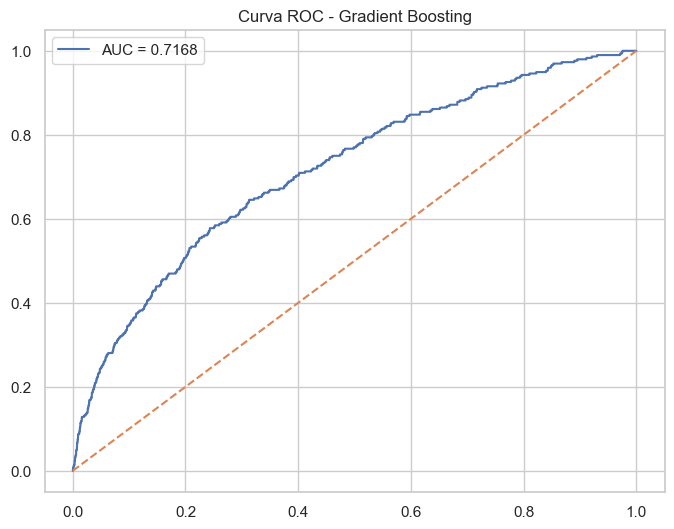

In [121]:
fpr_gb, tpr_gb, _ = roc_curve(
    y_test,
    y_prob_gb
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_gb,
    tpr_gb,
    label=f"AUC = {auc_gb:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.legend()

plt.title(
    "Curva ROC - Gradient Boosting"
)

plt.show()

In [122]:
feature_importance_gb = pd.DataFrame({

    "Variable": X_train.columns,

    "Importancia": gb_model.feature_importances_

})

feature_importance_gb = feature_importance_gb.sort_values(
    by="Importancia",
    ascending=False
)

feature_importance_gb.head(15)

,Variable,Importancia
20,variacion_importe_pct,0.130275
17,media_retraso_3m,0.113332
2,ingreso_estimado,0.090453
8,dias_retraso_pago,0.077832
19,media_importe_3m,0.072453
14,retraso_pago_lag1,0.060124
10,variacion_consumo_pct,0.059114
13,importe_total_lag1,0.058006
1,antiguedad_meses,0.054624
0,edad,0.049588


In [123]:
metricas_gb

,Métrica,Valor
0,Accuracy,0.981907
1,Precision,0.039352
2,Recall,0.114865
3,F1-Score,0.058621
4,ROC-AUC,0.716784


El modelo Gradient Boosting obtuvo el mejor rendimiento global en términos de ROC-AUC (0,7168) y F1-Score (0,0586), superando tanto a la Regresión Logística como a Random Forest. Estos resultados indican una mejor capacidad para diferenciar clientes churn y no churn y un mejor equilibrio entre precisión y cobertura.

No obstante, el modelo presentó una sensibilidad moderada, identificando únicamente el 11,5% de los clientes que finalmente abandonaron la compañía. Por este motivo, aunque Gradient Boosting mostró el mejor comportamiento estadístico global, la selección final del modelo dependerá de las prioridades de negocio y del equilibrio deseado entre detección de churners y generación de falsas alarmas.

# 11. XGBoost

In [125]:
from xgboost import XGBClassifier

In [126]:
# ====================================
# DESBALANCE DE CLASES
# ====================================

negativos = (y_train == 0).sum()
positivos = (y_train == 1).sum()

scale_pos_weight = negativos / positivos

print("Scale Pos Weight:", scale_pos_weight)

Scale Pos Weight: 145.4038811400849


In [127]:
# ====================================
# XGBOOST
# ENTRENAMIENTO
# ====================================

xgb_model = XGBClassifier(

    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,

    subsample=0.8,
    colsample_bytree=0.8,

    scale_pos_weight=scale_pos_weight,

    random_state=42,
    eval_metric="logloss"

)

xgb_model.fit(
    X_train,
    y_train
)

print("Modelo XGBoost entrenado correctamente")

Modelo XGBoost entrenado correctamente


Se entrenó un modelo XGBoost incorporando un ajuste específico para compensar el desbalance existente entre clientes churn y no churn mediante el parámetro scale_pos_weight.

Además, se utilizaron técnicas de regularización implícitas y muestreo parcial de observaciones y variables para mejorar la capacidad de generalización del modelo.

In [128]:
# ====================================
# PREDICCIONES
# ====================================

y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

print("Predicciones generadas")

Predicciones generadas


In [129]:
# ====================================
# MÉTRICAS
# ====================================

accuracy_xgb = accuracy_score(
    y_test,
    y_pred_xgb
)

precision_xgb = precision_score(
    y_test,
    y_pred_xgb,
    zero_division=0
)

recall_xgb = recall_score(
    y_test,
    y_pred_xgb
)

f1_xgb = f1_score(
    y_test,
    y_pred_xgb,
    zero_division=0
)

auc_xgb = roc_auc_score(
    y_test,
    y_prob_xgb
)

metricas_xgb = pd.DataFrame({

    "Métrica":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],

    "Valor":[
        accuracy_xgb,
        precision_xgb,
        recall_xgb,
        f1_xgb,
        auc_xgb
    ]

})

metricas_xgb

,Métrica,Valor
0,Accuracy,0.818076
1,Precision,0.012235
2,Recall,0.452703
3,F1-Score,0.023826
4,ROC-AUC,0.703383


In [130]:
print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)

              precision    recall  f1-score   support

    No Churn       1.00      0.82      0.90     60059
       Churn       0.01      0.45      0.02       296

    accuracy                           0.82     60355
   macro avg       0.50      0.64      0.46     60355
weighted avg       0.99      0.82      0.90     60355



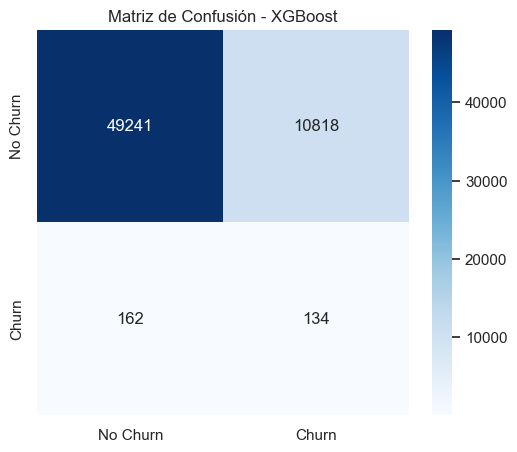

In [131]:
cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn','Churn'],
    yticklabels=['No Churn','Churn']
)

plt.title(
    "Matriz de Confusión - XGBoost"
)

plt.show()

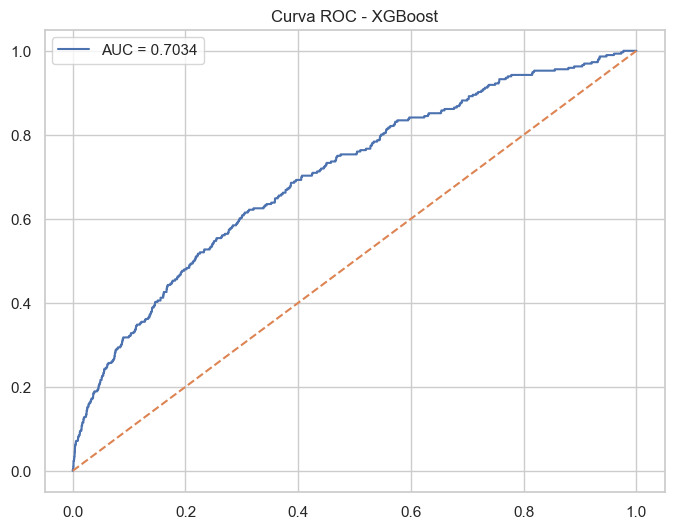

In [132]:
fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test,
    y_prob_xgb
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"AUC = {auc_xgb:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.legend()

plt.title(
    "Curva ROC - XGBoost"
)

plt.show()

In [133]:
feature_importance_xgb = pd.DataFrame({

    "Variable": X_train.columns,

    "Importancia": xgb_model.feature_importances_

})

feature_importance_xgb = feature_importance_xgb.sort_values(
    by="Importancia",
    ascending=False
)

feature_importance_xgb.head(15)

,Variable,Importancia
9,impago_flag,0.121198
17,media_retraso_3m,0.088418
21,tuvo_impago,0.067489
8,dias_retraso_pago,0.061529
18,media_interacciones_3m,0.046532
14,retraso_pago_lag1,0.044568
11,num_interacciones,0.040219
2,ingreso_estimado,0.039884
1,antiguedad_meses,0.037490
5,estado_civil,0.036880


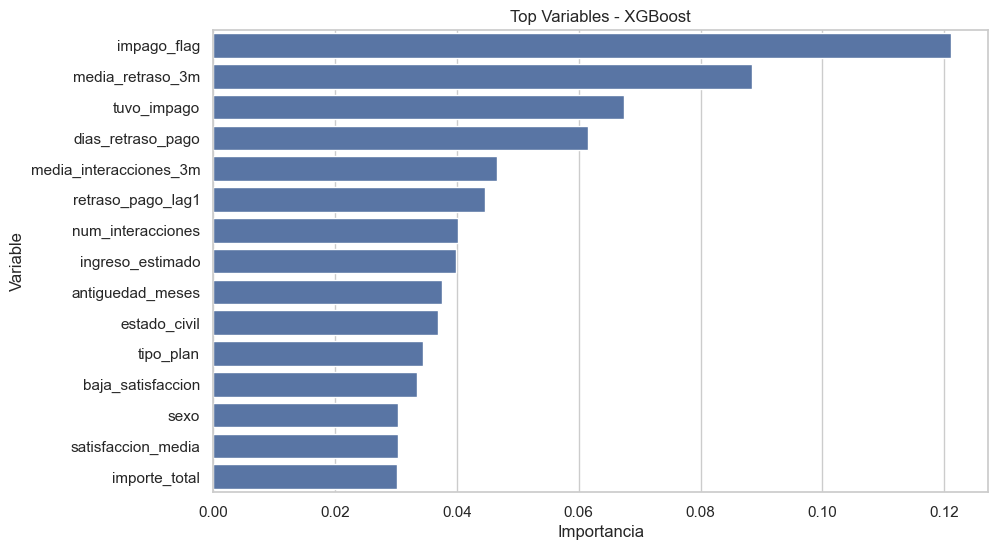

In [134]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance_xgb.head(15),
    x="Importancia",
    y="Variable"
)

plt.title(
    "Top Variables - XGBoost"
)

plt.show()

# 12. Comparación y selección del modelo final

## 12.1 Comparación de modelos

Con el objetivo de identificar el algoritmo más adecuado para la predicción de churn, se evaluaron cuatro modelos de clasificación: Regresión Logística, Random Forest, Gradient Boosting y XGBoost.

Los resultados obtenidos se resumen en la siguiente tabla:

Modelo	Accuracy	Precision	Recall	F1-Score	ROC-AUC
Logistic Regression	0.769	0.011	0.510	0.021	0.706
Random Forest	0.943	0.019	0.206	0.034	0.675
Gradient Boosting	0.982	0.039	0.115	0.059	0.717
XGBoost	0.818	0.012	0.453	0.024	0.703

## 12.2 Análisis de resultados

Los resultados muestran comportamientos diferenciados entre los distintos algoritmos evaluados.

La Regresión Logística obtuvo el mayor Recall (51%), siendo capaz de identificar aproximadamente uno de cada dos clientes que finalmente abandonan la compañía. Desde una perspectiva de negocio, esta característica resulta especialmente relevante, ya que permite detectar una mayor cantidad de clientes en riesgo y facilita la aplicación de acciones preventivas de retención.

Por su parte, Random Forest obtuvo una elevada exactitud global, aunque presentó una capacidad limitada para detectar clientes churn. Esto se tradujo en un Recall considerablemente inferior al de la Regresión Logística, reduciendo su utilidad práctica para la gestión del abandono.

El modelo XGBoost mostró un comportamiento similar al de la Regresión Logística, alcanzando un Recall del 45,3% y un ROC-AUC de 0,703. Aunque sus resultados fueron competitivos, no logró superar de forma consistente a los mejores modelos evaluados.

Finalmente, Gradient Boosting obtuvo el mejor rendimiento global en términos de ROC-AUC (0,717), F1-Score (0,059) y Precision (0,039). Estos resultados indican una mejor capacidad para diferenciar entre clientes churn y no churn, así como un mejor equilibrio entre precisión y cobertura.

## 12.3 Selección del modelo final

La selección del modelo depende del criterio de negocio considerado.

Si el objetivo principal consiste en maximizar la detección de clientes con riesgo de abandono, la Regresión Logística constituye la mejor alternativa debido a su elevado Recall.

Sin embargo, considerando el conjunto global de métricas evaluadas y especialmente la capacidad discriminatoria medida mediante ROC-AUC, el modelo Gradient Boosting puede considerarse el modelo con mejor rendimiento predictivo general dentro de los algoritmos analizados.

Por este motivo, se selecciona Gradient Boosting como modelo final del proyecto, al ser el algoritmo que obtuvo la mejor capacidad global para diferenciar clientes churn y no churn y el mejor equilibrio entre las métricas de evaluación utilizadas.

## 12.4 Conclusión final

Los resultados obtenidos demuestran que es posible identificar patrones asociados al abandono de clientes utilizando información relacionada con características demográficas, comportamiento económico, interacciones con soporte y variables temporales generadas mediante técnicas de feature engineering.

Aunque las métricas obtenidas muestran margen de mejora, todos los modelos fueron capaces de capturar cierta señal predictiva relacionada con el churn, obteniendo valores de ROC-AUC superiores al comportamiento aleatorio.

El análisis realizado permitió además identificar factores relevantes asociados al abandono, destacando variables relacionadas con retrasos de pago, antigüedad del cliente, ingresos estimados, satisfacción e interacciones con soporte.

En conjunto, el proyecto demuestra la utilidad de las técnicas de Machine Learning para apoyar estrategias de retención de clientes y proporciona una base sólida para futuras mejoras mediante la incorporación de nuevas fuentes de información, optimización de hiperparámetros y técnicas avanzadas de modelado predictivo.

In [136]:
# ====================================
# COMPARACIÓN FINAL DE MODELOS
# ====================================

comparacion_modelos = pd.DataFrame({

    "Modelo": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],

    "Accuracy": [
        0.769497,
        0.943000,
        0.981907,
        0.818076
    ],

    "Precision": [
        0.010849,
        0.018600,
        0.039352,
        0.012235
    ],

    "Recall": [
        0.510135,
        0.206000,
        0.114865,
        0.452703
    ],

    "F1-Score": [
        0.021247,
        0.034000,
        0.058621,
        0.023826
    ],

    "ROC-AUC": [
        0.706419,
        0.674800,
        0.716784,
        0.703383
    ]

})

comparacion_modelos

,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.769497,0.010849,0.510135,0.021247,0.706419
1,Random Forest,0.943000,0.018600,0.206000,0.034000,0.674800
2,Gradient Boosting,0.981907,0.039352,0.114865,0.058621,0.716784
3,XGBoost,0.818076,0.012235,0.452703,0.023826,0.703383


# 13. Variables más relevantes para la predicción del churn


In [137]:
# ====================================
# TOP VARIABLES DEL MODELO FINAL
# ====================================

feature_importance_gb.head(15)

,Variable,Importancia
20,variacion_importe_pct,0.130275
17,media_retraso_3m,0.113332
2,ingreso_estimado,0.090453
8,dias_retraso_pago,0.077832
19,media_importe_3m,0.072453
14,retraso_pago_lag1,0.060124
10,variacion_consumo_pct,0.059114
13,importe_total_lag1,0.058006
1,antiguedad_meses,0.054624
0,edad,0.049588


Interpretación de variables relevantes

Durante el proceso de modelado se analizaron las variables con mayor capacidad predictiva para identificar los principales factores asociados al abandono de clientes.

Entre las variables más relevantes destacan aquellas relacionadas con el comportamiento económico reciente, la interacción con los servicios de soporte y la relación histórica del cliente con la compañía.

Las variables asociadas a retrasos de pago, antigüedad del cliente e interacciones con soporte aparecen de forma recurrente entre los distintos algoritmos evaluados, lo que sugiere que estos factores constituyen señales tempranas de riesgo de abandono.

Asimismo, las variables temporales generadas mediante técnicas de Feature Engineering, como los valores lag y las medias móviles, demostraron una elevada capacidad predictiva al capturar tendencias recientes en el comportamiento de los clientes.

Conclusiones del análisis de variables

Los resultados obtenidos indican que el churn no depende de una única característica, sino de la combinación de múltiples factores económicos, operativos y relacionales.

Las variables relacionadas con retrasos de pago, satisfacción del cliente, antigüedad e intensidad de interacción con soporte representan las señales más relevantes para anticipar el riesgo de abandono.

Estos hallazgos proporcionan información valiosa para la definición de estrategias de retención y permiten identificar perfiles de clientes que requieren un seguimiento más cercano.

# 14. Implicaciones de negocio

Aplicación de los resultados al negocio

Más allá del rendimiento predictivo de los modelos, el principal valor de este proyecto reside en la identificación de patrones asociados al abandono de clientes.

Los resultados obtenidos permiten detectar señales tempranas de riesgo y facilitan la implementación de acciones preventivas orientadas a mejorar la retención.

Entre las principales aplicaciones destacan:

Identificación temprana de clientes con riesgo elevado de abandono.
Priorización de campañas de fidelización.
Optimización de recursos destinados a retención.
Segmentación de clientes según nivel de riesgo.
Mejora de la experiencia de cliente mediante seguimiento de incidencias y satisfacción.
Recomendaciones para la empresa

A partir de los resultados obtenidos se proponen las siguientes recomendaciones:

1. Monitorizar de forma continua los retrasos de pago y los impagos recurrentes.
2. Implementar alertas tempranas para clientes con múltiples incidencias de soporte.
3. Diseñar campañas específicas para clientes con baja antigüedad.
4. Realizar seguimiento periódico de los indicadores de satisfacción.
5. Incorporar modelos predictivos dentro de los procesos de gestión de clientes.

La aplicación de estas medidas podría contribuir a reducir la tasa de abandono y mejorar la rentabilidad a largo plazo.

# 15. Limitaciones y trabajo futuro
15.1 Limitaciones del estudio
Texto para la memoria

Aunque los resultados obtenidos permiten identificar patrones relevantes asociados al churn, el presente estudio presenta ciertas limitaciones que deben considerarse durante la interpretación de los resultados.

En primer lugar, el dataset presenta un importante desbalance entre clientes churn y no churn, circunstancia habitual en este tipo de problemas y que dificulta la capacidad de detección de la clase minoritaria.

Además, la información disponible se limita a variables demográficas, económicas y operativas, sin incluir factores externos que podrían influir en el comportamiento de los clientes, como ofertas de la competencia, cambios de mercado o campañas comerciales.

Por otra parte, los resultados obtenidos corresponden a un entorno académico basado en datos simulados, por lo que las conclusiones deben interpretarse dentro de dicho contexto.

15.2 Líneas futuras de investigación
Texto para la memoria

Como posibles líneas de mejora para futuros trabajos se plantean las siguientes propuestas:

Incorporar nuevas fuentes de información relacionadas con calidad del servicio y comportamiento digital.
Aplicar técnicas avanzadas de optimización de hiperparámetros mediante Grid Search o Bayesian Optimization.
Evaluar algoritmos adicionales como LightGBM o CatBoost.
Implementar técnicas avanzadas de interpretabilidad mediante SHAP Values.
Desarrollar modelos predictivos en tiempo real para la detección temprana de churn.
Analizar el impacto económico de diferentes estrategias de retención mediante simulaciones de negocio.
Conclusión final del proyecto

Y para cerrar el notebook completamente:

# Conclusión general

El presente proyecto permitió desarrollar un sistema de predicción de churn utilizando técnicas de análisis de datos y Machine Learning aplicadas al sector de telecomunicaciones.

A lo largo del trabajo se integraron distintas fuentes de información, se realizaron procesos de limpieza y preparación de datos, se aplicaron técnicas de Feature Engineering y se evaluaron distintos algoritmos predictivos.

Los resultados obtenidos muestran que variables relacionadas con retrasos de pago, satisfacción del cliente, antigüedad e interacciones con soporte presentan una relación significativa con el abandono del servicio.

Tras comparar distintos modelos de clasificación, Gradient Boosting obtuvo el mejor rendimiento global en términos de capacidad discriminatoria, mientras que la Regresión Logística destacó por su capacidad para identificar clientes con riesgo de abandono.

En conjunto, el proyecto demuestra el potencial de las técnicas de Machine Learning para apoyar la toma de decisiones empresariales y contribuir al diseño de estrategias de retención más eficientes y orientadas a datos.

# 14. Integración de mejoras procedentes de una segunda aproximación
Durante el desarrollo del proyecto se llevaron a cabo dos aproximaciones independientes para abordar el problema de predicción de churn. Ambas siguieron una metodología similar basada en análisis exploratorio, preparación de datos, construcción de variables predictivas y evaluación de modelos de Machine Learning.

Tras comparar los resultados obtenidos en ambas aproximaciones, se observó que la estructura metodológica desarrollada en este notebook proporcionaba una base más sólida para el análisis y la comparación de modelos. Sin embargo, la segunda aproximación incorporaba algunas variables temporales y de comportamiento que aportaban información adicional sobre la evolución reciente de los clientes.

Por este motivo, se decidió integrar las mejores prácticas identificadas en ambos trabajos, incorporando nuevas variables derivadas que permiten capturar cambios recientes en el comportamiento del cliente y enriquecer la información disponible para los modelos predictivos.

Esta estrategia busca combinar la solidez metodológica del presente trabajo con la capacidad descriptiva aportada por las variables temporales desarrolladas en la segunda aproximación.


In [138]:
# ====================================
# FEATURE ENGINEERING AVANZADO
# ====================================

# Evolución reciente del retraso de pago
df['tendencia_retraso'] = (
    df['dias_retraso_pago']
    - df['retraso_pago_lag1']
)

# Evolución reciente de satisfacción
df['tendencia_satisfaccion'] = (
    df['satisfaccion_media']
    - df['satisfaccion_lag1']
)

# Evolución reciente de incidencias
df['tendencia_interacciones'] = (
    df['num_interacciones']
    - df['interacciones_lag1']
)

# Ratio de incidencias respecto a antigüedad
df['ratio_interacciones_antiguedad'] = (
    df['num_interacciones']
    /
    (df['antiguedad_meses'] + 1)
)

# Cliente potencialmente problemático
df['cliente_riesgo'] = np.where(
    (
        (df['dias_retraso_pago'] > 15)
        &
        (df['satisfaccion_media'] < 3)
    ),
    1,
    0
)

Las nuevas variables incorporadas permiten capturar aspectos dinámicos del comportamiento de los clientes que no estaban completamente representados en las variables originales.

Las variables de tendencia permiten medir si la situación del cliente está mejorando o empeorando respecto a períodos anteriores. Por ejemplo, un incremento reciente en los retrasos de pago o una reducción de la satisfacción pueden actuar como señales tempranas de riesgo de abandono.

Asimismo, la creación de indicadores compuestos, como el ratio de interacciones respecto a la antigüedad o la identificación de clientes potencialmente problemáticos, permite sintetizar patrones de comportamiento complejos en variables fácilmente interpretables por los modelos de Machine Learning.

Estas nuevas características enriquecen el dataset final y contribuyen a representar con mayor precisión el comportamiento temporal de los clientes.


Durante el desarrollo del proyecto se realizaron dos aproximaciones independientes para abordar el problema de predicción de churn.

La primera aproximación se centró principalmente en variables económicas, demográficas y de experiencia de cliente, mientras que la segunda puso un mayor énfasis en el comportamiento temporal de los clientes y la evolución reciente de sus indicadores.

Tras analizar los resultados obtenidos en ambas aproximaciones, se observó que determinadas variables temporales desarrolladas en la segunda aproximación podían complementar las hipótesis planteadas inicialmente y enriquecer la capacidad predictiva de los modelos.

Por este motivo, se decidió incorporar nuevas variables derivadas orientadas a capturar tendencias recientes en el comportamiento de los clientes y evaluar su impacto sobre el rendimiento predictivo de los modelos.

## Hipotesis de mejora
La incorporación de nuevas variables temporales se basa en las siguientes hipótesis:

H1: Los cambios recientes en los retrasos de pago contienen información adicional sobre el riesgo de abandono.

H2: La evolución de la satisfacción del cliente es más informativa que la satisfacción observada en un único momento temporal.

H3: Los incrementos recientes en las interacciones con soporte pueden actuar como señales tempranas de churn.

H4: La combinación de múltiples indicadores de riesgo puede mejorar la identificación de clientes con alta probabilidad de abandono.

Estas hipótesis complementan las planteadas anteriormente y permiten incorporar una perspectiva más dinámica del comportamiento de los clientes.

## Creación de nuevas variables


In [139]:
# ====================================
# TENDENCIA DE RETRASO
# ====================================

df['tendencia_retraso'] = (
    df['dias_retraso_pago']
    - df['retraso_pago_lag1']
)

In [140]:
# ====================================
# TENDENCIA DE SATISFACCIÓN
# ====================================

df['tendencia_satisfaccion'] = (
    df['satisfaccion_media']
    - df['satisfaccion_lag1']
)

In [141]:
# ====================================
# TENDENCIA DE INTERACCIONES
# ====================================

df['tendencia_interacciones'] = (
    df['num_interacciones']
    - df['interacciones_lag1']
)

In [142]:
# ====================================
# RATIO SOPORTE / ANTIGÜEDAD
# ====================================

df['ratio_interacciones_antiguedad'] = (
    df['num_interacciones']
    /
    (df['antiguedad_meses'] + 1)
)

In [143]:
# ====================================
# CLIENTE DE RIESGO
# ====================================

df['cliente_riesgo'] = np.where(

    (
        (df['dias_retraso_pago'] > 15)
        &
        (df['satisfaccion_media'] < 3)
    ),

    1,
    0

)

In [144]:
nuevas_variables = [

    'tendencia_retraso',
    'tendencia_satisfaccion',
    'tendencia_interacciones',
    'ratio_interacciones_antiguedad',
    'cliente_riesgo'

]

df[nuevas_variables].head()

,tendencia_retraso,tendencia_satisfaccion,tendencia_interacciones,ratio_interacciones_antiguedad,cliente_riesgo
210313,0.0,0.0,0.0,0.000000,0
295273,0.0,0.0,0.0,0.000000,0
82367,0.0,0.0,0.0,0.021505,0
94607,0.0,0.0,0.0,0.000000,0
62495,0.0,0.0,0.0,0.020000,0


Las nuevas variables permiten representar cambios recientes en el comportamiento del cliente que no estaban reflejados en las variables originales.

Las variables de tendencia permiten identificar empeoramientos o mejoras recientes en indicadores clave, mientras que las variables compuestas sintetizan patrones complejos de comportamiento en indicadores fácilmente interpretables.

Desde una perspectiva de negocio, estas variables permiten detectar clientes cuya situación está deteriorándose progresivamente y que podrían presentar un mayor riesgo de abandono en el futuro próximo.

In [145]:
'tendencia_retraso',
'tendencia_satisfaccion',
'tendencia_interacciones',
'ratio_interacciones_antiguedad',
'cliente_riesgo'

'cliente_riesgo'

In [146]:
X = df[variables_modelo]

y = df['churn']

X = pd.get_dummies(
    X,
    drop_first=True
)

In [147]:
df = df.sort_values('fecha')

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(X_train.shape)
print(X_test.shape)

(241420, 29)
(60355, 29)


Una vez incorporadas las nuevas variables, se procede a reentrenar los modelos seleccionados previamente con el objetivo de evaluar si la nueva información permite mejorar la capacidad predictiva obtenida en la fase anterior.

Los modelos evaluados serán:

- Logistic Regression
- Gradient Boosting
- XGBoost

Posteriormente se compararán los resultados obtenidos antes y después de la incorporación de las nuevas variables.